# Setup

In [290]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import matplotlib.pyplot as plt
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Check for CUDA and if available, use that device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## Global parameters and train/test data

In [291]:
# Global parameters
#optimizer
batch_size = 128
num_epochs = 50

seed = 2222
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
    
#data augmentation
#train/test split

In [292]:
train_transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.RandomHorizontalFlip(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

test_transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
#trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

val_split_ratio = 0.2
num_train = len(trainset)
indices = list(range(num_train))
split = int(torch.floor(torch.tensor(num_train * val_split_ratio)))

# Shuffle the indices for random splitting
torch.manual_seed(42) # for reproducibility
torch.randperm(len(indices))

train_indices, val_indices = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_indices)
val_sampler = SubsetRandomSampler(val_indices)

train_loader = DataLoader(trainset, batch_size=batch_size, sampler=train_sampler, num_workers=2)
val_loader = DataLoader(trainset, batch_size=batch_size, sampler=val_sampler, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Helper Functions

## Train/test

In [293]:
def train_model(model, data_loader, val_loader, criterion, optimizer, num_epochs, device='cpu', full_verbose=False):
    train_losses = []
    mini_batch_losses = []
    train_accuracies = []
    val_accuracies = []
    epoch_times = []

    print(f'Begin training on {device}')
    
    start_time = time.perf_counter()
    model = model.to(device)

    for epoch in range(num_epochs):  # loop over the dataset multiple times
        epoch_start = time.perf_counter()
        model.train()
        
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0
        
        for i, data in enumerate(data_loader):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)
            # zero the parameter gradients
            optimizer.zero_grad()
    
            # forward + backward + optimize
            outputs = model(inputs)
            outputs.to(device)
            loss = criterion(outputs, labels)
            loss.backward() # Computes gradients
            optimizer.step() # Updates parameters using the computed gradients
    
            # print statistics
            running_loss += loss.item()
            mini_batch_losses.append(loss.item())
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            if (i % 100 == 99) & full_verbose:    # print every 2000 mini-batches
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 100:.3f}')
                running_loss = 0.0

        model.eval() # Set model to evaluation mode (disables Dropout, uses running stats for Batch Norm)
        with torch.no_grad():
            correct_predictions_val = 0
            total_samples_val = 0
            for val_data in val_loader:
                inputs_val, labels_val = val_data
                inputs_val = inputs_val.to(device)
                labels_val = labels_val.to(device)
                
                outputs_val = model(inputs_val)
                _, predicted_val = torch.max(outputs_val.data, 1)
                total_samples_val += labels_val.size(0)
                correct_predictions_val += (predicted_val == labels_val).sum().item()
                
        epoch_loss = running_loss / len(trainloader)
        train_losses.append(epoch_loss)
        
        epoch_accuracy = 100 * correct_predictions / total_samples
        epoch_accuracy_val = 100 * correct_predictions_val / total_samples_val
        train_accuracies.append(epoch_accuracy)
        val_accuracies.append(epoch_accuracy_val)
        
        epoch_end = time.perf_counter()
        epoch_time = epoch_end - epoch_start
        epoch_times.append(epoch_time)

        print(f'Epoch {epoch + 1}, Loss: {epoch_loss:.3f}, Accuracy: {epoch_accuracy:.2f}%, Validation accuracy: {epoch_accuracy_val:.2f}%,, Time: {epoch_time:.0f}s')

    end_time = time.perf_counter()
    train_time = end_time - start_time
    print('Finished Training')

    return(model, train_losses, mini_batch_losses, train_accuracies, val_accuracies, epoch_times, train_time)

In [294]:
def test_model(model, test_loader, device='cpu'):
    correct = 0
    total = 0

    y = torch.tensor([]).to(device)
    y_hat = torch.tensor([]).to(device)

    pred_times = []
    model.eval()
    
    with torch.no_grad(): # Disable gradient calculation for evaluation
        for data in test_loader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)

            start_time = time.perf_counter()
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            end_time = time.perf_counter()

            pred_times.append(end_time - start_time)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            #y.extend(labels.clone().to('cpu').numpy())
            #y_hat.extend(predicted.clone().to('cpu').numpy())

            y = torch.cat((y, labels))
            y_hat = torch.cat((y_hat, predicted))

    y = y.clone().to('cpu').numpy()
    y_hat = y_hat.clone().to('cpu').numpy()

    model_results = pd.DataFrame({'y':y, 'y_pred':y_hat})
    model_results['count'] = (model_results['y'] == model_results['y_pred'])
    model_results = model_results.groupby(['y','y_pred'], as_index=False).count()
    confusion_matrix = model_results.pivot(index='y', columns='y_pred', values='count')

    out_class = [ x for x in range(0,10) ]
    accuracies = []
    precisions = []
    recalls = []
    f1s = []
    
    for i in range(0,10):
        y_true = (y==float(i))
        y_pred = (y_hat==float(i))
    
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
    
        accuracies.append(accuracy)
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
    
    metrics_df = pd.DataFrame({'y':out_class, 'precision':precisions, 'recall':recalls, 'F1':f1s})

    report = classification_report(y, y_hat)

    category_counts = model_results.groupby('y',as_index=False).sum()[['y','count']]
    category_corrects = model_results[model_results['y'] == model_results['y_pred']][['y','count']].rename({'count':'correct'},axis=1)
    accuracy_df = category_corrects.merge(category_counts, on='y')
    accuracy_df['accuracy'] = accuracy_df['correct'] / accuracy_df['count']

    metrics_df = metrics_df.merge(accuracy_df, how='left', on='y')
    
    total_pred_time = sum(pred_times)
    unit_pred_time = total_pred_time / total
    
    #print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f}%')

    return(accuracy_score(y,y_hat), metrics_df, confusion_matrix, report, total_pred_time, unit_pred_time)

## Utilities

In [295]:
def calculate_size(input_size, kernel_size, padding=0, stride=1):
    return( ( (input_size + 2*padding - (kernel_size -1) -1 ) /stride +1) )

In [308]:
def switch_dictionary(grid_results):
    inner_keys = grid_results[list(grid_results.keys())[0]].keys()
    
    new_dict = {}
    for j in inner_keys:
        inner_dict = {}
        for k in grid_results.keys():
            inner_dict[k] = grid_results[k][j]
        new_dict[j] = inner_dict

    return new_dict

## Plotting

### Single model plots

In [491]:
def generate_training_plots(mini_batch_losses, train_losses, train_accuracies, val_accuracies, file_name=None):    
    fig1 = plt.figure(figsize=(16,9))
    fig1.suptitle('Performance metrics')
    
    ax = fig1.subplots(2,1)
    
    ax[0].plot(mini_batch_losses)
    ax[0].set_ylabel("Mini-batch losses")

    color = "tab:blue"
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].plot(train_losses, label='Epoch loss')
    ax[1].tick_params(axis='y', labelcolor=color)
    
    ax2 = ax[1].twinx()
    
    color = "tab:red"
    ax2.set_ylabel("Accuracy", color=color)
    ax2.plot(train_accuracies, color=color, label='Train accuracy')
    ax2.plot(val_accuracies, color='tab:green', label='Validation accuracy')
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.legend()
    
    fig1.tight_layout()

    if file_name is not None:
        plt.savefig(file_name)
    
    plt.show()

### Multiple model plots

In [492]:
def generate_epoch_plots(results, file_name=None):
    colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:purple']
    plots = ['losses', 'train_accuracies', 'val_accuracies', 'epoch_times']
    title = ['Epoch loss', 'Training Accuracy', 'Validation accuracy', 'Epoch runtime']
    models = list(results[plots[0]].keys())
    
    fig1 = plt.figure(figsize=(16,9))
    fig1.suptitle('Performance metrics')
    
    ax = fig1.subplots(2,2)

    for i, axis in enumerate(ax.flatten(),0):
        axis.set_xlabel("Epoch")
        axis.set_ylabel(title[i])
        for j, model in enumerate(results[plots[i]],0):
            axis.plot(results[plots[i]][model], label=models[j])
        axis.tick_params(axis='y', labelcolor=colors[j])
        axis.legend()

    fig1.tight_layout()

    if file_name is not None:
        plt.savefig(file_name)
        
    plt.show()

In [497]:
def generate_mini_batch_plot(results, file_name=None):
    colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:purple']
    plot = 'mini_batch_losses'
    title = 'Mini-batch losses'
    models = list(results[plot].keys())
    
    fig1 = plt.figure(figsize=(16,9))
    fig1.suptitle(title)
    
    ax = fig1.subplots(2,2)
    min_value = 2
    max_value = 1
    for model in results[plot].keys():
        model_max = np.max(results[plot][model])
        model_min = np.min(results[plot][model])

        max_value = model_max if model_max > max_value else max_value
        min_value = model_min if model_min < min_value else min_value

    print(min_value, max_value)
    
    for i, axis in enumerate(ax.flatten(),0):
        axis.set_xlabel("Mini-batch")
        axis.set_ylabel(models[i])
        axis.plot(results[plot][models[i]], label=models[i], color=colors[i])
        axis.set_ylim(min_value*0.9,max_value*1.1)
        axis.tick_params(axis='y', labelcolor=colors[i])
        axis.legend()

    fig1.tight_layout()

    if file_name is not None:
        plt.savefig(file_name)
        
    plt.show()

In [496]:
def generate_total_runtime_plot(results, file_name=None):
    colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:purple']
    plot = 'train_time'
    title = 'Total train time (m)'
    models = list(results[plot].keys())
    
    fig1 = plt.figure(figsize=(16,9))
    fig1.suptitle(title)
    values = []
    for model in results[plot].keys():
        values.append(results[plot][model]/60)

    #plt.set_xlabel("Mini-batch")
    #plt.set_ylabel(models[i])
    plt.bar(models, values, )
    plt.tick_params(axis='y')
    plt.tight_layout()

    if file_name is not None:
        plt.savefig(file_name)
    
    plt.show()

# Multi-layer Perceptron

## Model definition

In [414]:
class MLP(nn.Module):
    def __init__(self, num_classes=10, layers=3, batch_norm=False, dropout=False):
        super(MLP, self).__init__()

        print('-'*30)
        print('* Layers:')
        
        self.fc1 = nn.Linear(3 * 32 * 32, 512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)
        
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2 if layers == 2 else 0.5)
        
        self.fc3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.5)

        last_layer_input = 128 if layers == 3 else 256 
        self.fc4 = nn.Linear(last_layer_input, num_classes)
        self.sigmoid = nn.Sigmoid()

        self.layers = layers
        self.batch_norm = batch_norm
        self.dropout = dropout

        print('* Parameters:')
        print(f'Layers: {self.layers}')
        print(f'Dropout: {self.dropout}')
        print(f'Last layer input: {last_layer_input}')        

    def forward(self, x):
        x = x.view(-1, 3 * 32 * 32) # Flatten the image
        
        x = self.relu1(self.fc1(x))
        x = (self.dropout1(x) if self.dropout else x)
        x = self.relu2(self.fc2(x))
        x = (self.dropout2(x) if self.dropout else x)
        
        if self.layers == 3:
            x = self.relu3(self.fc3(x))
            x = (self.dropout3(x) if self.dropout else x)
            
        x = self.fc4(x)
        x = self.sigmoid(x)
        return x

## Training multiple  models

In [415]:
models_mlp = {'mlp_2L': MLP(num_classes=10, layers=2, batch_norm=False, dropout=False),
              'mlp_2L_do': MLP(num_classes=10, layers=2, batch_norm=True, dropout=True),
              'cnn_3L': MLP(num_classes=10, layers=3, batch_norm=False, dropout=False),
              'cnn_3L_do': MLP(num_classes=10, layers=3, batch_norm=True, dropout=True)}

------------------------------
* Layers:
* Parameters:
Layers: 2
Dropout: False
Last layer input: 256
------------------------------
* Layers:
* Parameters:
Layers: 2
Dropout: True
Last layer input: 256
------------------------------
* Layers:
* Parameters:
Layers: 3
Dropout: False
Last layer input: 128
------------------------------
* Layers:
* Parameters:
Layers: 3
Dropout: True
Last layer input: 128


In [416]:
grid_results_mlp = {}

num_epochs = 50

for model_name in models_mlp.keys():
    results = {}

    print(f'------- Loading model {model_name}')
    model = models_mlp[model_name]

    criterion = nn.CrossEntropyLoss() 
    optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimization

    (trained_model, 
     train_losses, 
     mini_batch_losses,
     train_accuracies, 
     val_accuracies, 
     epoch_times, 
     train_time_gpu) = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)


    results['model'] = trained_model
    results['losses'] = train_losses
    results['mini_batch_losses'] = mini_batch_losses
    results['train_accuracies'] = train_accuracies
    results['val_accuracies'] = val_accuracies
    results['epoch_times'] = epoch_times
    results['train_time'] = train_time_gpu

    grid_results_mlp[model_name] = results

------- Loading model mlp_2L
Begin training on cuda:0
Epoch 1, Loss: 1.991, Accuracy: 34.99%, Validation accuracy: 39.49%,, Time: 23s
Epoch 2, Loss: 1.925, Accuracy: 40.98%, Validation accuracy: 43.52%,, Time: 23s
Epoch 3, Loss: 1.899, Accuracy: 43.24%, Validation accuracy: 44.54%,, Time: 22s
Epoch 4, Loss: 1.880, Accuracy: 45.91%, Validation accuracy: 46.14%,, Time: 23s
Epoch 5, Loss: 1.867, Accuracy: 46.83%, Validation accuracy: 44.67%,, Time: 24s
Epoch 6, Loss: 1.857, Accuracy: 47.58%, Validation accuracy: 46.83%,, Time: 22s
Epoch 7, Loss: 1.844, Accuracy: 48.59%, Validation accuracy: 47.10%,, Time: 21s
Epoch 8, Loss: 1.837, Accuracy: 49.27%, Validation accuracy: 47.66%,, Time: 20s
Epoch 9, Loss: 1.831, Accuracy: 49.76%, Validation accuracy: 48.64%,, Time: 21s
Epoch 10, Loss: 1.822, Accuracy: 50.16%, Validation accuracy: 48.12%,, Time: 20s
Epoch 11, Loss: 1.818, Accuracy: 51.01%, Validation accuracy: 47.11%,, Time: 21s
Epoch 12, Loss: 1.811, Accuracy: 51.65%, Validation accuracy: 48

In [ ]:
with open('grid_results_nlp_filename.pickle', 'wb') as file:
    pickle.dump(grid_results_mlp, file)

### Softmax results

In [435]:
with open('grid_results_mlp_softmax.pickle', 'rb') as file:
    grid_results_mlp_sigmoid = pickle.load(file)

In [436]:
new_dict = switch_dictionary(grid_results_mlp_sigmoid)

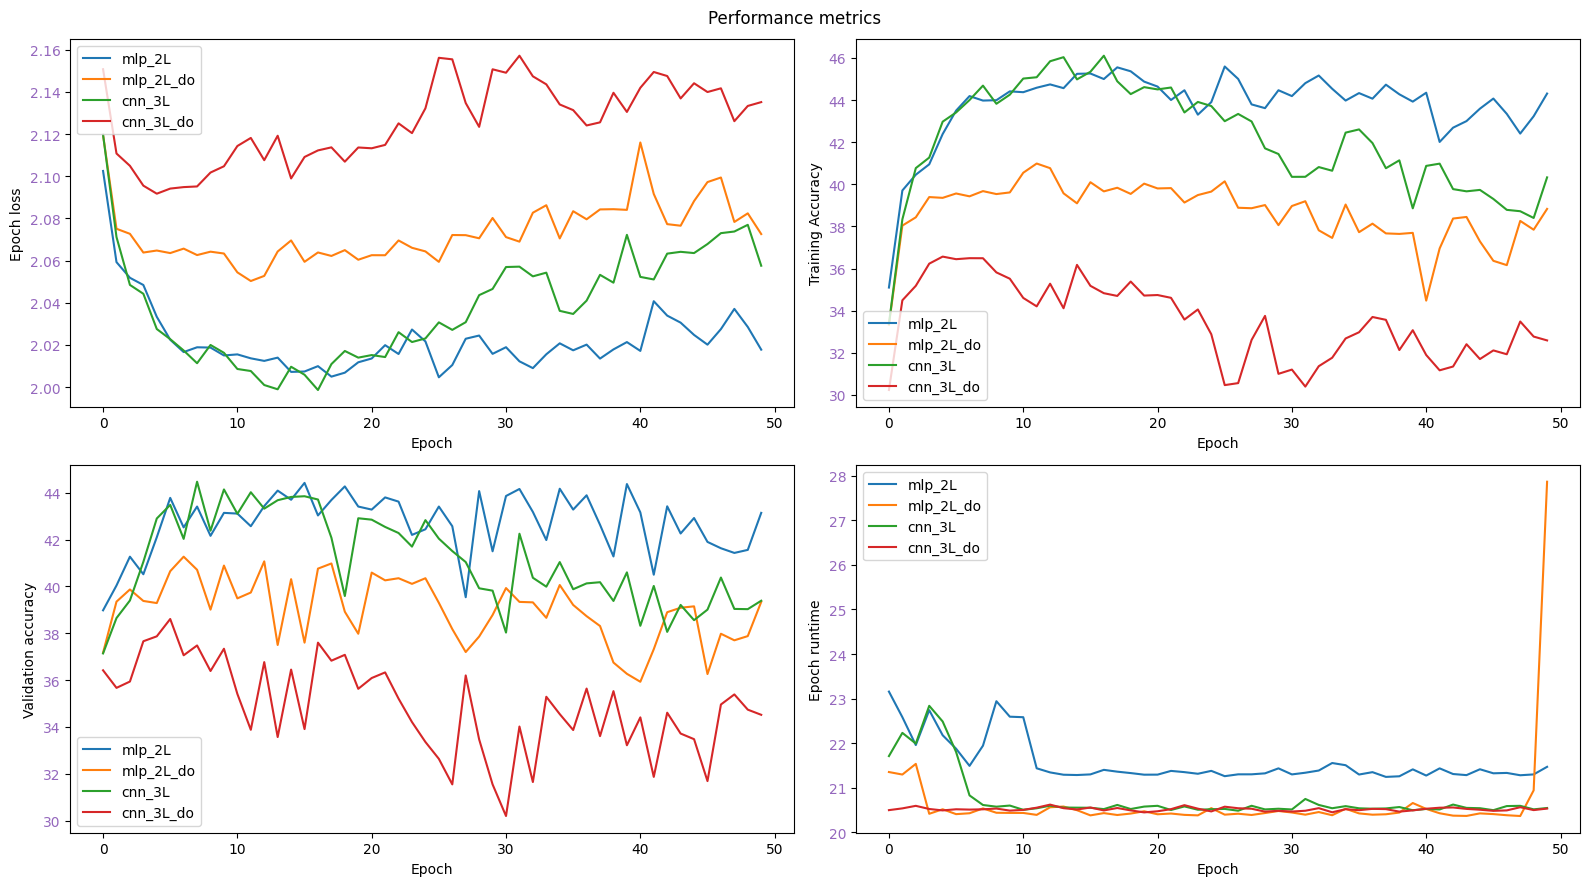

In [437]:
generate_epoch_plots(new_dict)

1.8248207569122314 2.303250789642334


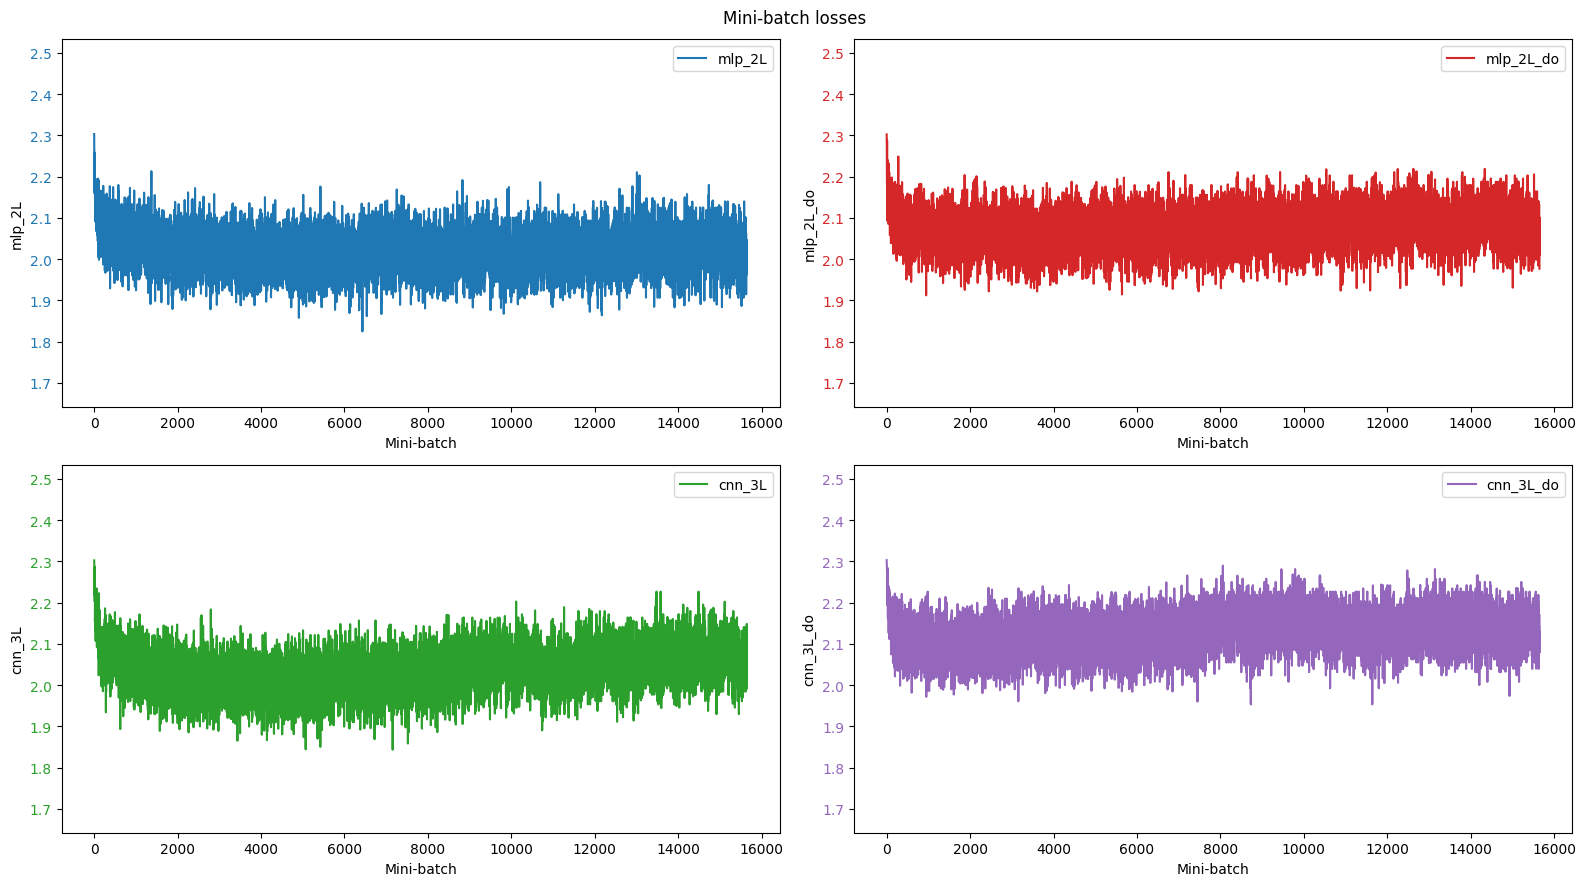

In [438]:
generate_mini_batch_plot(new_dict)

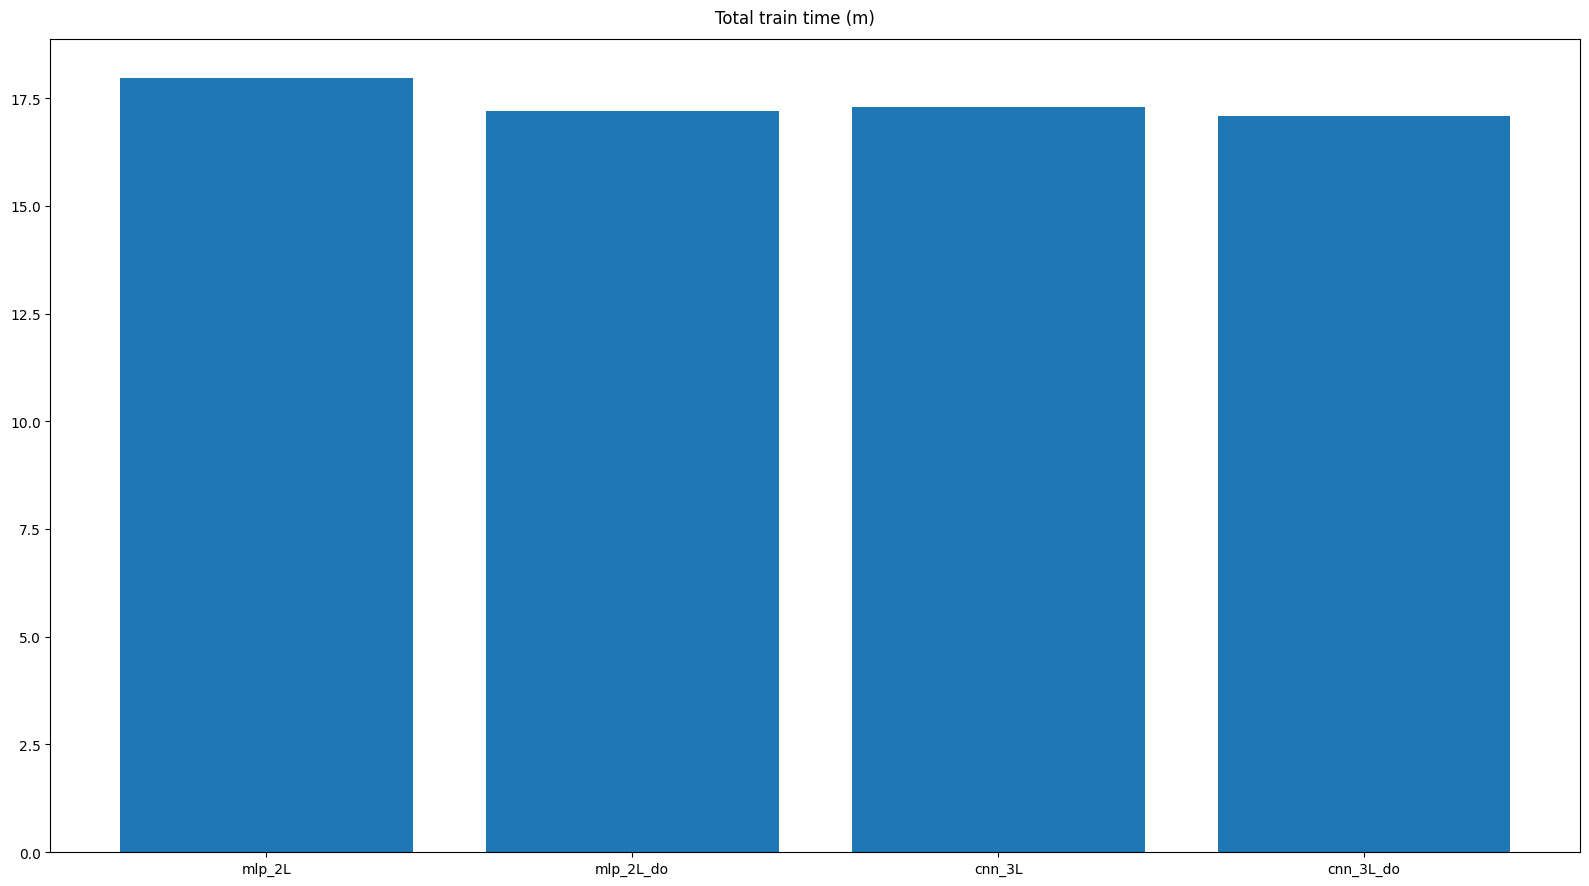

In [439]:
generate_total_runtime_plot(new_dict)

### Sigmoid

In [552]:
with open('grid_results_mlp_sigmoid.pickle', 'rb') as file:
    grid_results_with_activations = pickle.load(file)

In [553]:
new_dict = switch_dictionary(grid_results_mlp)

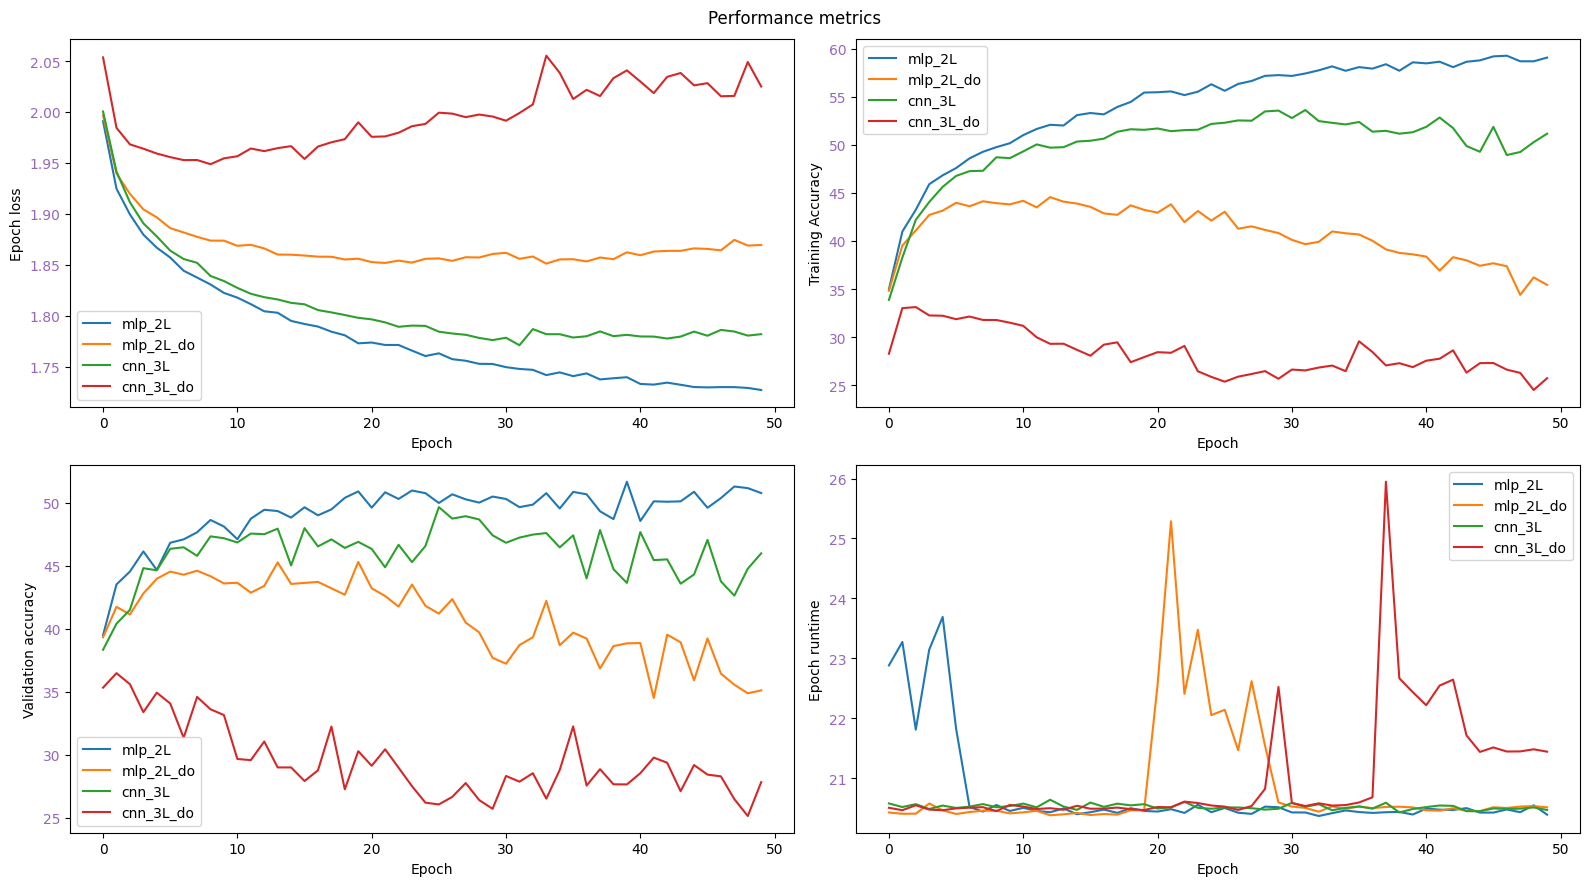

In [554]:
generate_epoch_plots(new_dict, 'mlp_performance_sigmoid.png')

1.636532187461853 2.302098274230957


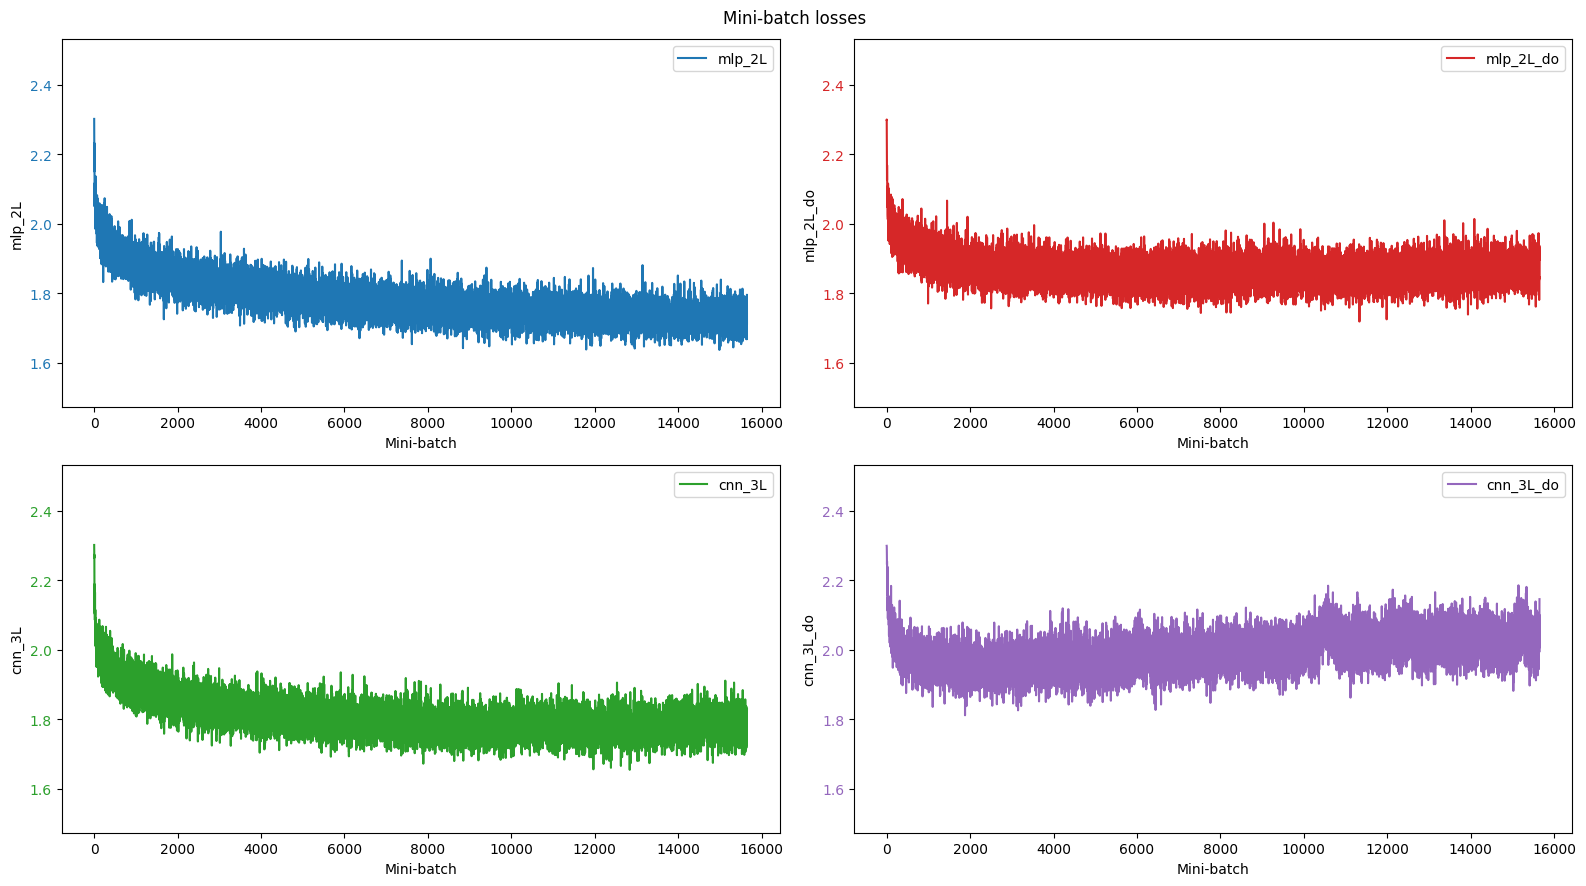

In [420]:
generate_mini_batch_plot(new_dict)

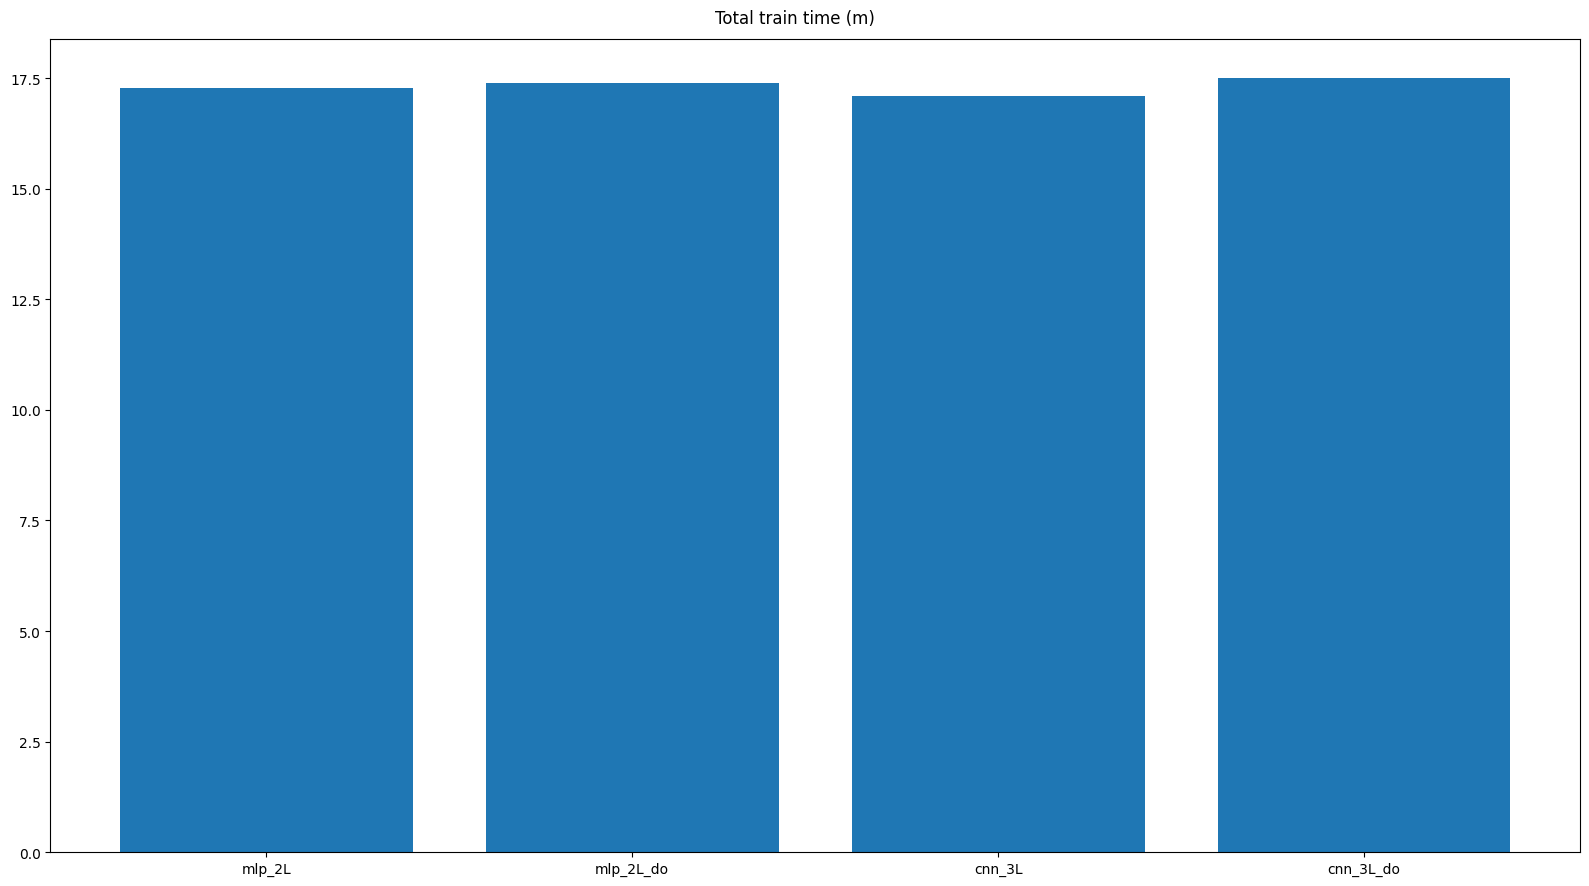

In [421]:
generate_total_runtime_plot(new_dict)

## Training on cpu

In [440]:
models_mlp_cpu = {'mlp_2L': MLP(num_classes=10, layers=2, batch_norm=False, dropout=False),
              'mlp_2L_do': MLP(num_classes=10, layers=2, batch_norm=True, dropout=True),
              'cnn_3L': MLP(num_classes=10, layers=3, batch_norm=False, dropout=False),
              'cnn_3L_do': MLP(num_classes=10, layers=3, batch_norm=True, dropout=True)}

------------------------------
* Layers:
* Parameters:
Layers: 2
Dropout: False
Last layer input: 256
------------------------------
* Layers:
* Parameters:
Layers: 2
Dropout: True
Last layer input: 256
------------------------------
* Layers:
* Parameters:
Layers: 3
Dropout: False
Last layer input: 128
------------------------------
* Layers:
* Parameters:
Layers: 3
Dropout: True
Last layer input: 128


In [441]:
grid_results_mlp_cpu = {}

num_epochs = 50

for model_name in models_mlp_cpu.keys():
    results = {}

    print(f'------- Loading model {model_name}')
    model = models_mlp_cpu[model_name]

    criterion = nn.CrossEntropyLoss() 
    optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimization

    (trained_model, 
     train_losses, 
     mini_batch_losses,
     train_accuracies, 
     val_accuracies, 
     epoch_times, 
     train_time_gpu) = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device='cpu')


    results['model'] = trained_model
    results['losses'] = train_losses
    results['mini_batch_losses'] = mini_batch_losses
    results['train_accuracies'] = train_accuracies
    results['val_accuracies'] = val_accuracies
    results['epoch_times'] = epoch_times
    results['train_time'] = train_time_gpu

    grid_results_mlp_cpu[model_name] = results

------- Loading model mlp_2L
Begin training on cpu
Epoch 1, Loss: 1.988, Accuracy: 35.12%, Validation accuracy: 37.48%,, Time: 40s
Epoch 2, Loss: 1.930, Accuracy: 39.22%, Validation accuracy: 40.58%,, Time: 21s
Epoch 3, Loss: 1.906, Accuracy: 42.08%, Validation accuracy: 42.43%,, Time: 21s
Epoch 4, Loss: 1.886, Accuracy: 43.77%, Validation accuracy: 43.66%,, Time: 22s
Epoch 5, Loss: 1.876, Accuracy: 44.73%, Validation accuracy: 44.28%,, Time: 21s
Epoch 6, Loss: 1.864, Accuracy: 46.18%, Validation accuracy: 46.15%,, Time: 21s
Epoch 7, Loss: 1.855, Accuracy: 45.84%, Validation accuracy: 46.04%,, Time: 21s
Epoch 8, Loss: 1.845, Accuracy: 47.66%, Validation accuracy: 46.55%,, Time: 21s
Epoch 9, Loss: 1.838, Accuracy: 48.45%, Validation accuracy: 46.88%,, Time: 21s
Epoch 10, Loss: 1.836, Accuracy: 48.10%, Validation accuracy: 45.52%,, Time: 21s
Epoch 11, Loss: 1.829, Accuracy: 49.52%, Validation accuracy: 47.89%,, Time: 21s
Epoch 12, Loss: 1.820, Accuracy: 50.10%, Validation accuracy: 47.44

In [442]:
with open('grid_results_mlp_cpu.pickle', 'wb') as file:
    pickle.dump(grid_results_mlp_cpu, file)

In [443]:
new_dict = switch_dictionary(grid_results_mlp_cpu)

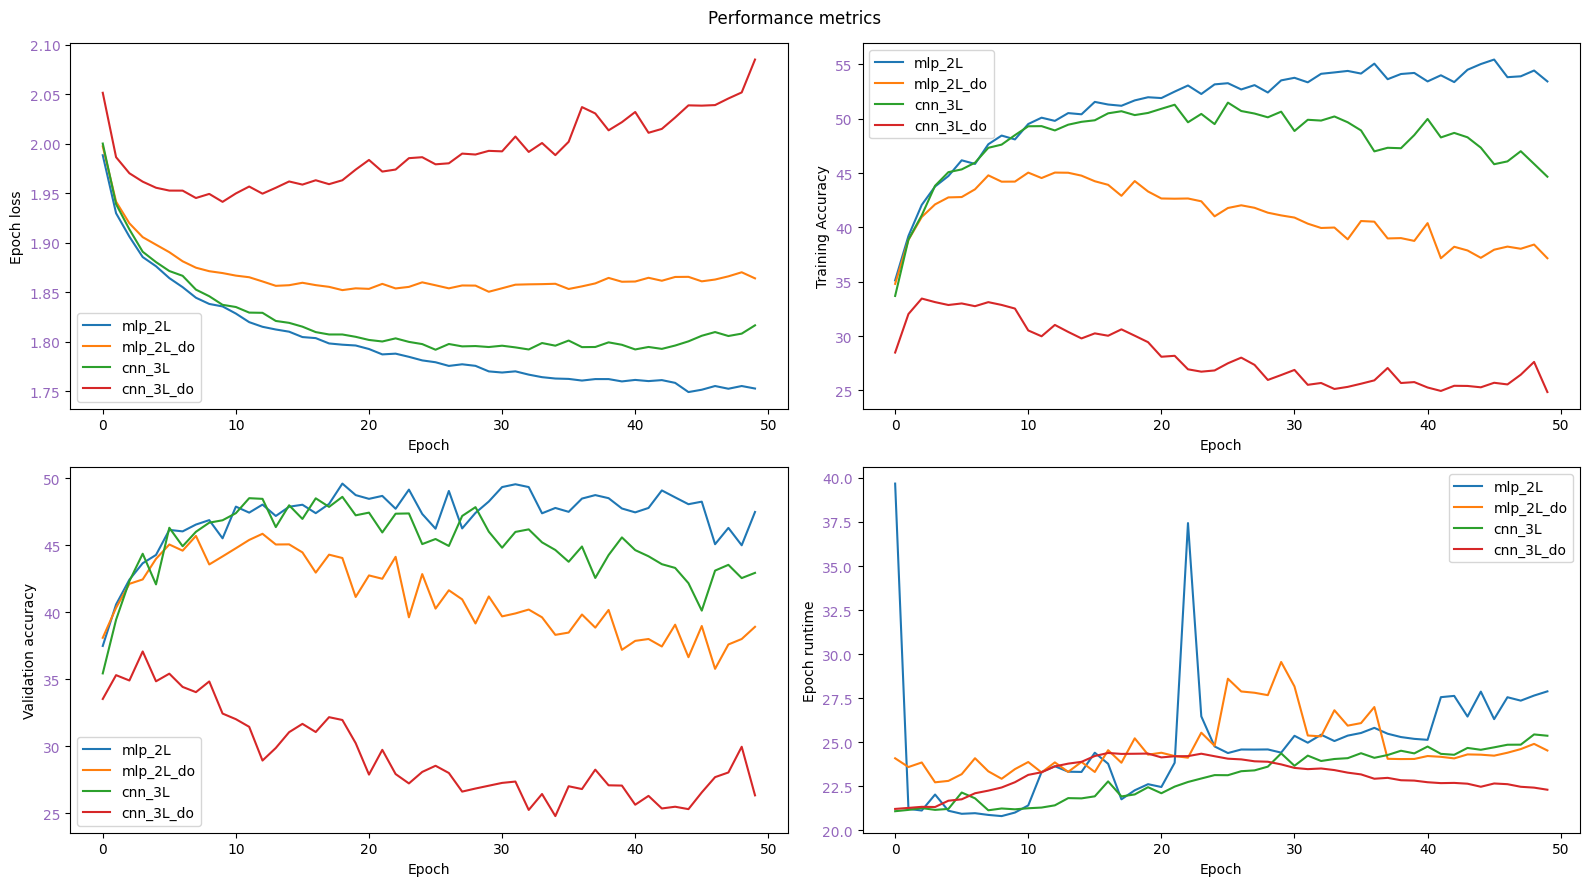

In [493]:
generate_epoch_plots(new_dict, 'mlp_performance_sigmoid_cpu.png')

1.6413687467575073 2.3041884899139404


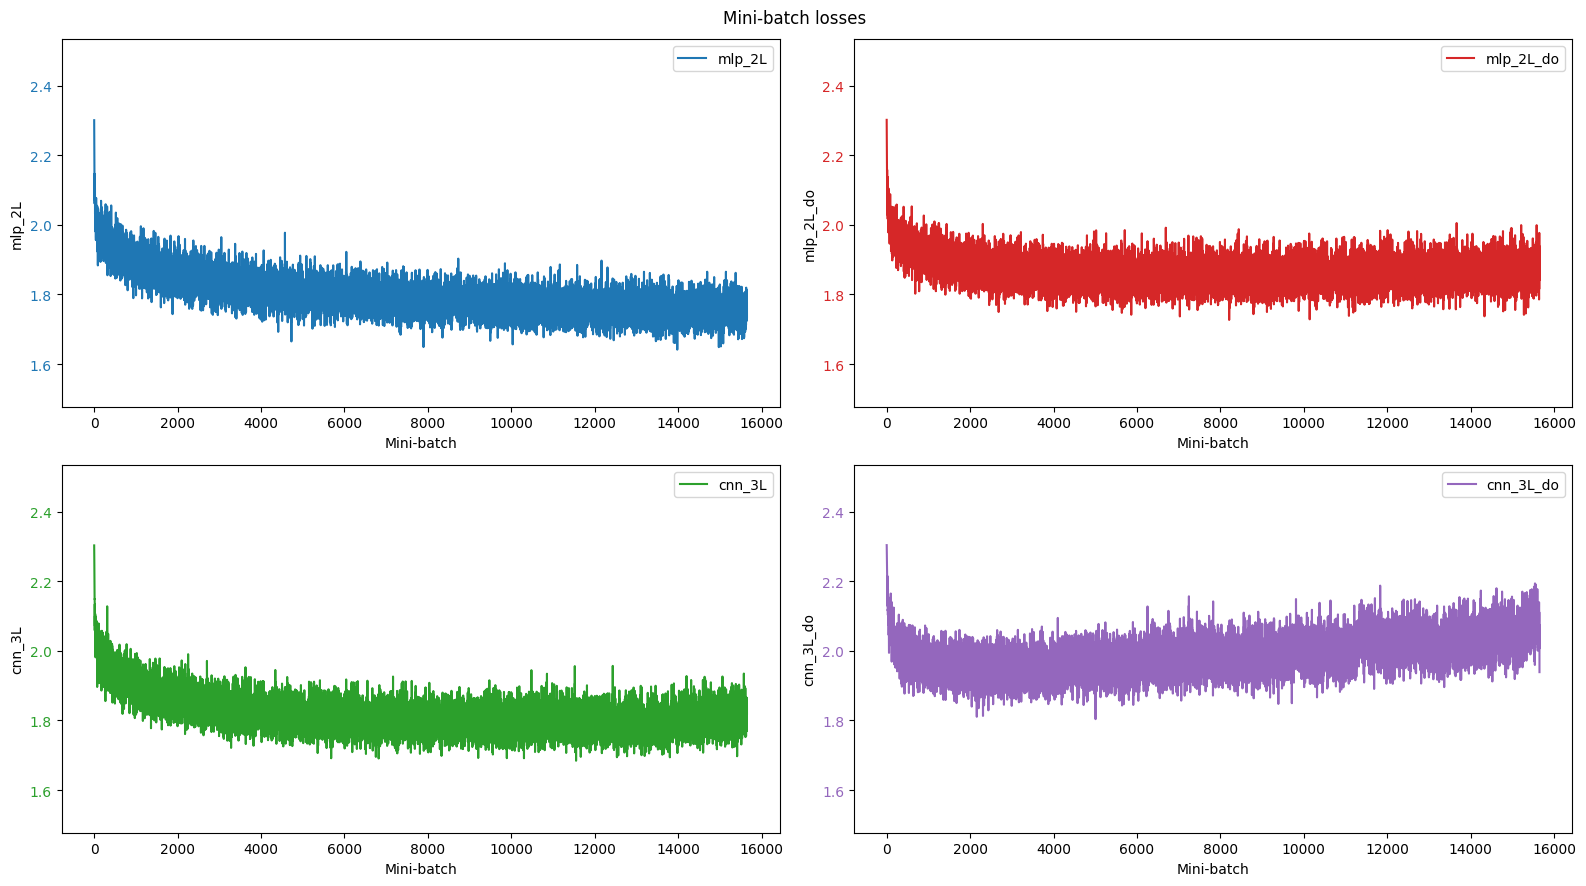

In [498]:
generate_mini_batch_plot(new_dict, 'mlp_mini_batch_sigmoid_cpu.png')

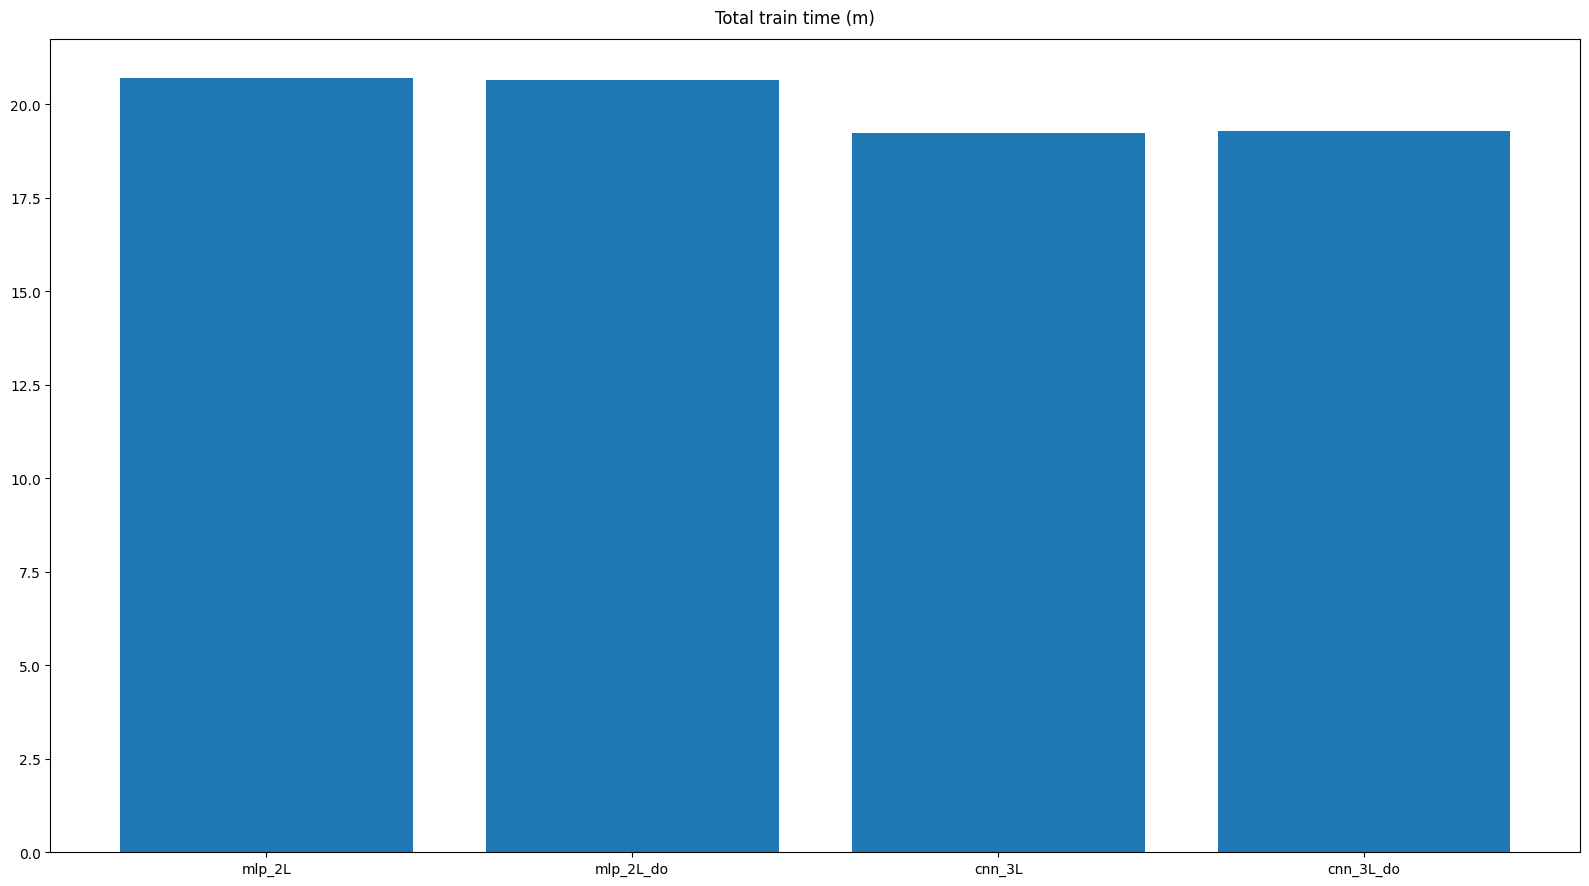

In [499]:
generate_total_runtime_plot(new_dict, 'mlp_runtimes_cpu.png')

## Comparing GPU vs. CPU

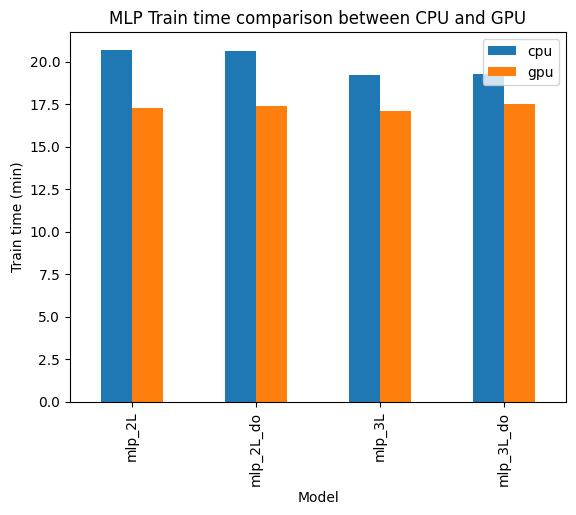

In [573]:
#grid_results_mlp, grid_results_mlp_cpu

grid_resuls_mlp_r = switch_dictionary(grid_results_mlp)
grid_resuls_mlp_cpu_r = switch_dictionary(grid_results_mlp_cpu)

gpu = pd.DataFrame(grid_resuls_mlp_r['train_time'].values(), grid_resuls_mlp_r['train_time'].keys()).rename({0:'gpu'},axis=1)
cpu = pd.DataFrame(grid_resuls_mlp_cpu_r['train_time'].values(), grid_resuls_mlp_cpu_r['train_time'].keys()).rename({0:'cpu'}, axis=1)

comparison = gpu.join(cpu)
comparison = comparison / 60
comparison = comparison.rename({'cnn_3L': 'mlp_3L', 'cnn_3L_do':'mlp_3L_do'},axis=0)
comparison = comparison.reset_index().rename({'index':'model'}, axis=1)

comparison.plot(x='model', y=['cpu', 'gpu'], kind='bar')
plt.title('MLP Train time comparison between CPU and GPU')
plt.ylabel('Train time (min)')
plt.xlabel('Model')
plt.savefig('mlp_train_time_comparison.png')
plt.show()

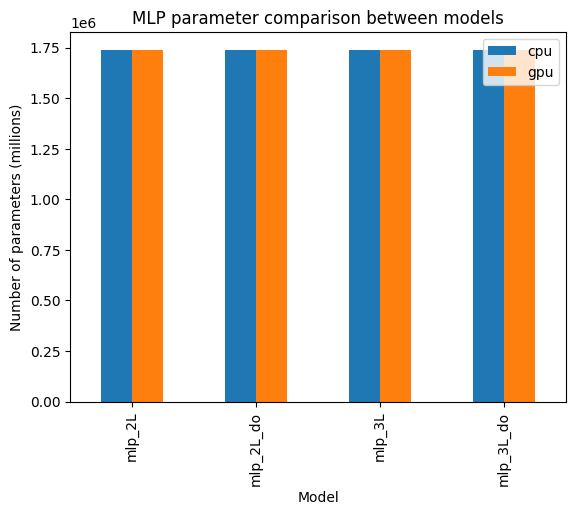

In [577]:
grid_resuls_mlp_r = switch_dictionary(grid_results_mlp)
grid_resuls_mlp_cpu_r = switch_dictionary(grid_results_mlp_cpu)

gpu = pd.DataFrame([sum(p.numel() for p in x.parameters()) for x in grid_resuls_mlp_r['model'].values()], grid_resuls_mlp_r['train_time'].keys()).rename({0:'gpu'},axis=1)
cpu = pd.DataFrame([sum(p.numel() for p in x.parameters()) for x in grid_resuls_mlp_cpu_r['model'].values()], grid_resuls_mlp_cpu_r['train_time'].keys()).rename({0:'cpu'}, axis=1)

comparison = gpu.join(cpu)
comparison = comparison.rename({'cnn_3L': 'mlp_3L', 'cnn_3L_do':'mlp_3L_do'},axis=0)
comparison = comparison.reset_index().rename({'index':'model'}, axis=1)

comparison.plot(x='model', y=['cpu', 'gpu'], kind='bar')
plt.title('MLP parameter comparison between models')
plt.ylabel('Number of parameters (millions)')
plt.xlabel('Model')
plt.savefig('mlp_parameter_comparison.png')
plt.show()

## Champion model

After reviewing all data, looks like the most comprehensive model with 50 epocs could be the 4 layer CNN with batch normalization, dropout in all stages and sigmoid output, so it was trained for 100 epocs

### Training 100 epochs

In [612]:
models_only_2L = {'mlp_2L': MLP(num_classes=10, layers=2, batch_norm=False, dropout=False)}

------------------------------
* Layers:
* Parameters:
Layers: 2
Dropout: False
Last layer input: 256


In [613]:
grid_results_with_activations_only2L = {}

num_epochs = 100

for model_name in models_only_2L.keys():
    results = {}

    print(f'------- Loading model {model_name}')
    model = models_only_2L[model_name]

    criterion = nn.CrossEntropyLoss() 
    optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimization

    (trained_model, 
     train_losses, 
     mini_batch_losses,
     train_accuracies, 
     val_accuracies, 
     epoch_times, 
     train_time_gpu) = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)


    results['model'] = trained_model
    results['losses'] = train_losses
    results['mini_batch_losses'] = mini_batch_losses
    results['train_accuracies'] = train_accuracies
    results['val_accuracies'] = val_accuracies
    results['epoch_times'] = epoch_times
    results['train_time'] = train_time_gpu

    grid_results_with_activations_only2L[model_name] = results

------- Loading model mlp_2L
Begin training on cuda:0
Epoch 1, Loss: 1.986, Accuracy: 35.68%, Validation accuracy: 38.61%,, Time: 22s
Epoch 2, Loss: 1.926, Accuracy: 39.78%, Validation accuracy: 41.71%,, Time: 22s
Epoch 3, Loss: 1.903, Accuracy: 42.72%, Validation accuracy: 43.08%,, Time: 22s
Epoch 4, Loss: 1.886, Accuracy: 44.81%, Validation accuracy: 45.02%,, Time: 22s
Epoch 5, Loss: 1.875, Accuracy: 45.84%, Validation accuracy: 45.43%,, Time: 22s
Epoch 6, Loss: 1.860, Accuracy: 47.16%, Validation accuracy: 46.27%,, Time: 23s
Epoch 7, Loss: 1.850, Accuracy: 47.70%, Validation accuracy: 46.65%,, Time: 23s
Epoch 8, Loss: 1.847, Accuracy: 48.12%, Validation accuracy: 47.09%,, Time: 24s
Epoch 9, Loss: 1.836, Accuracy: 49.39%, Validation accuracy: 48.39%,, Time: 22s
Epoch 10, Loss: 1.831, Accuracy: 49.59%, Validation accuracy: 46.53%,, Time: 23s
Epoch 11, Loss: 1.825, Accuracy: 50.00%, Validation accuracy: 48.24%,, Time: 23s
Epoch 12, Loss: 1.819, Accuracy: 50.47%, Validation accuracy: 46

In [615]:
with open('model_performance_mlp_only2L', 'wb') as file:
    pickle.dump(grid_results_with_activations_only2L, file)

In [616]:
new_dict = switch_dictionary(grid_results_with_activations_only2L)

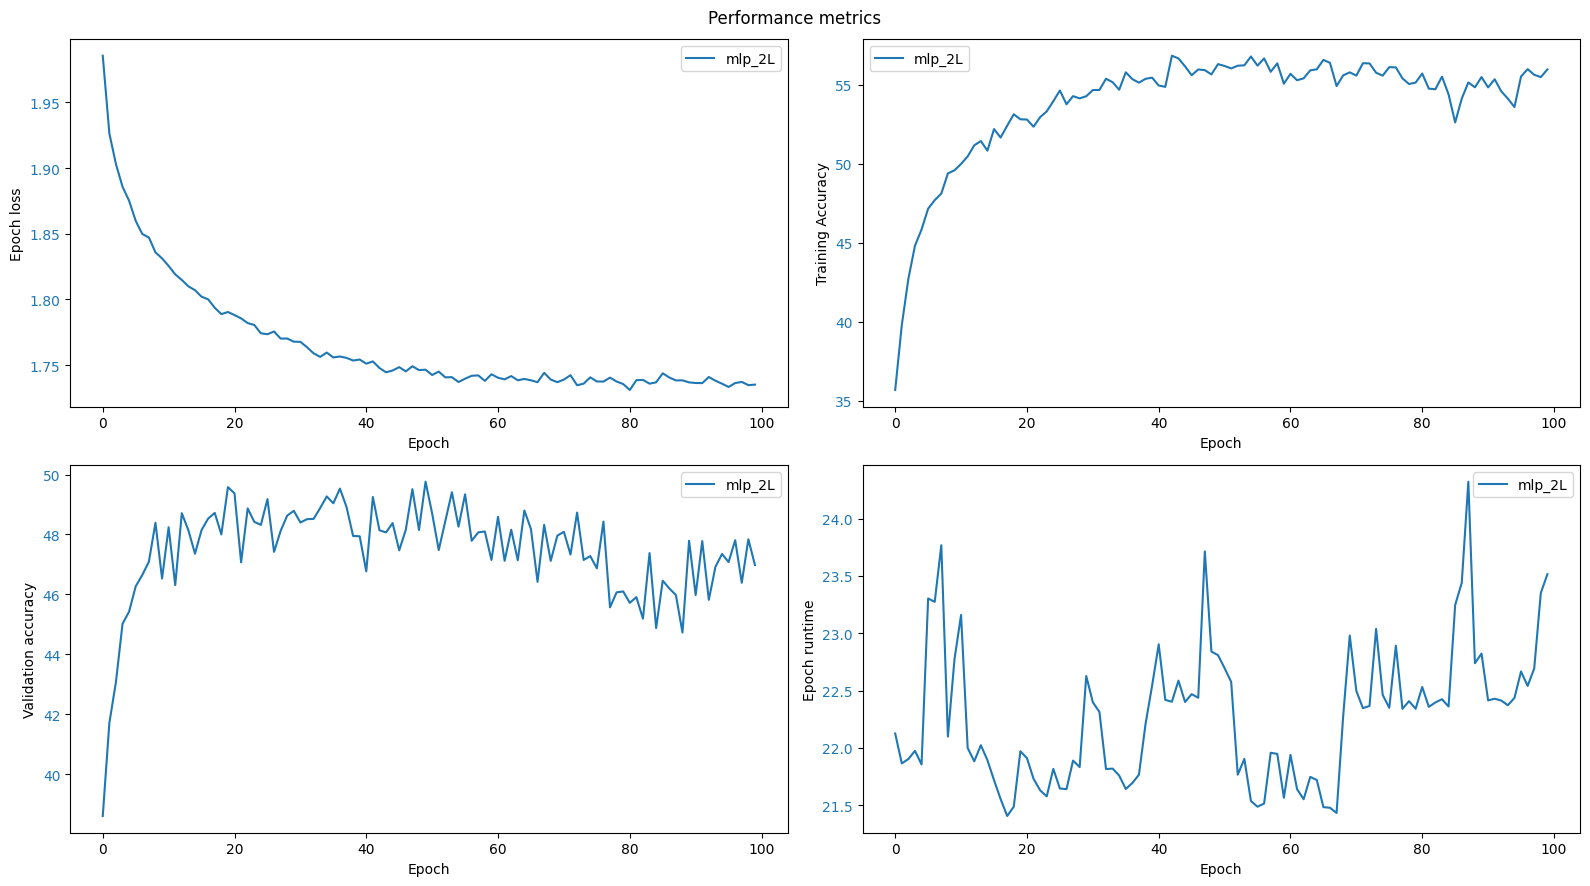

In [617]:
generate_epoch_plots(new_dict)

### Plot train performance metrics

In [618]:
new_dict = grid_results_with_activations_only2L['mlp_2L']

In [619]:
new_dict.keys()

dict_keys(['model', 'losses', 'mini_batch_losses', 'train_accuracies', 'val_accuracies', 'epoch_times', 'train_time'])

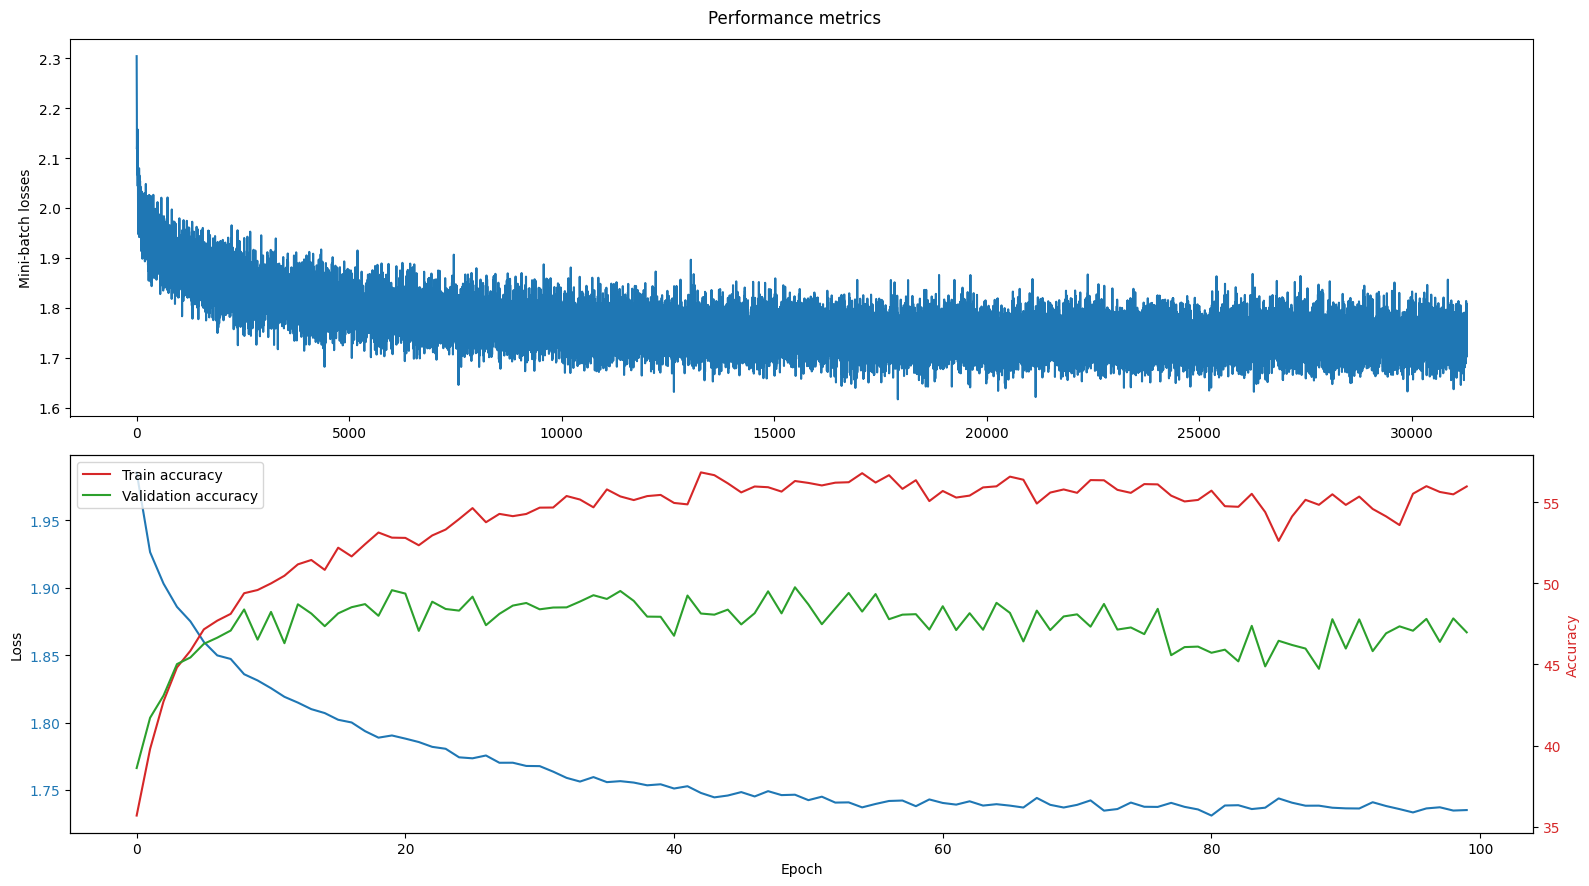

In [620]:
generate_training_plots(new_dict['mini_batch_losses'], new_dict['losses'], new_dict['train_accuracies'], new_dict['val_accuracies'], 'cnn_champion_performance.png')

In [621]:
print(f'Total Train time in gpu {new_dict['train_time']/60:.2f} min')

Total Train time in gpu 37.12 min


In [622]:
total_params = sum(p.numel() for p in new_dict['model'].parameters())
trainable_params = sum(p.numel() for p in new_dict['model'].parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 1740170
Trainable parameters: 1740170


### Model validation

In [623]:
cnn1_accuracy, cnn1_metrics, cnn1_confusion_matrix, cnn1_classification_report, cnn1_total_pred_time, cnn1_unit_pred_time = test_model(new_dict['model'], val_loader, device=device)

In [624]:
cnn1_accuracy, cnn1_total_pred_time, cnn1_unit_pred_time 

(0.4748, 0.02445219992659986, 2.445219992659986e-06)

In [625]:
print(cnn1_classification_report)

              precision    recall  f1-score   support

         0.0       0.48      0.71      0.58      1005
         1.0       0.52      0.74      0.61       974
         2.0       0.31      0.53      0.39      1032
         3.0       0.32      0.47      0.38      1016
         4.0       0.46      0.41      0.43       999
         5.0       0.34      0.13      0.19       937
         6.0       0.60      0.40      0.48      1030
         7.0       0.69      0.50      0.58      1001
         8.0       0.67      0.45      0.54      1025
         9.0       0.67      0.39      0.49       981

    accuracy                           0.47     10000
   macro avg       0.51      0.47      0.47     10000
weighted avg       0.51      0.47      0.47     10000



In [626]:
cnn1_metrics['y'] = cnn1_metrics['y'].apply(lambda x: classes[x])

In [627]:
cnn1_metrics

,y,precision,recall,F1,correct,count,accuracy
0,plane,0.482480,0.712438,0.575331,716,1005,0.712438
1,car,0.518385,0.738193,0.609064,719,974,0.738193
2,bird,0.314302,0.528101,0.394071,545,1032,0.528101
3,cat,0.324508,0.470472,0.384090,478,1016,0.470472
4,deer,0.460586,0.409409,0.433492,409,999,0.409409
5,dog,0.339833,0.130203,0.188272,122,937,0.130203
6,frog,0.600000,0.399029,0.479300,411,1030,0.399029
7,horse,0.689227,0.498501,0.578551,499,1001,0.498501
8,ship,0.672938,0.453659,0.541958,465,1025,0.453659
9,truck,0.667826,0.391437,0.493573,384,981,0.391437


In [628]:
class_names = {}
for i,name in enumerate(classes):
    class_names[i]=classes[i]

cnn1_confusion_matrix = cnn1_confusion_matrix.rename(class_names,axis=1).rename(class_names,axis=0)
cnn1_confusion_matrix

y_pred,plane,car,bird,cat,deer,dog,frog,horse,ship,truck
y,,,,,,,,,,
plane,716,54,65,22,13,13,10,23,62,27
car,73,719,18,26,21,6,21,5,30,55
bird,149,34,545,80,97,21,52,24,17,13
cat,48,30,224,478,44,45,71,27,20,29
deer,66,19,294,88,409,18,25,53,16,11
dog,39,39,200,420,40,122,30,29,13,5
frog,16,27,185,199,121,44,411,5,15,7
horse,48,37,139,65,111,63,16,499,10,13
ship,258,125,31,51,24,11,15,14,465,31


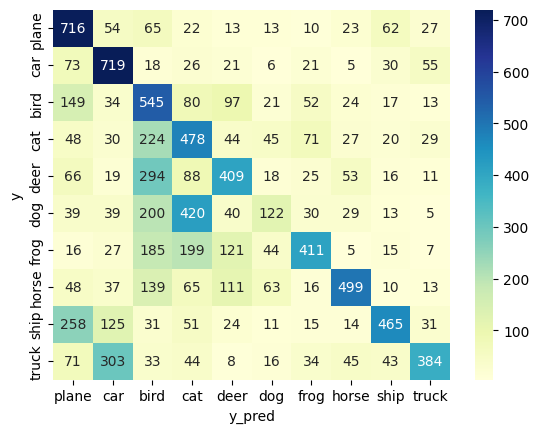

In [629]:
fig, ax = plt.subplots()
sns.heatmap(cnn1_confusion_matrix, annot=True, fmt='.0f', cmap='YlGnBu')
plt.savefig('mlp_champion_confusion_matrix.png')

In [366]:
cnn1_metrics

,y,precision,recall,F1,correct,count,accuracy
0,0,0.872863,0.812935,0.841834,817,1005,0.812935
1,1,0.950166,0.880903,0.914225,858,974,0.880903
2,2,0.849650,0.706395,0.771429,729,1032,0.706395
3,3,0.724176,0.648622,0.684320,659,1016,0.648622
4,4,0.714511,0.906907,0.799294,906,999,0.906907
5,5,0.762573,0.695838,0.727679,652,937,0.695838
6,6,0.806672,0.915534,0.857663,943,1030,0.915534
7,7,0.867265,0.868132,0.867698,869,1001,0.868132
8,8,0.885553,0.920976,0.902917,944,1025,0.920976
9,9,0.882865,0.929664,0.905660,912,981,0.929664


In [367]:
cnn1_confusion_matrix

y_pred,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0
y,,,,,,,,,,
0.0,817.0,12.0,31.0,13.0,19.0,4.0,9.0,14.0,65.0,21.0
1.0,7.0,858.0,1.0,6.0,3.0,4.0,14.0,NaN,18.0,63.0
2.0,37.0,3.0,729.0,28.0,103.0,36.0,61.0,21.0,11.0,3.0
3.0,12.0,1.0,28.0,659.0,80.0,114.0,70.0,31.0,10.0,11.0
4.0,5.0,NaN,18.0,12.0,906.0,9.0,25.0,20.0,3.0,1.0
5.0,2.0,2.0,19.0,148.0,50.0,652.0,21.0,39.0,NaN,4.0
6.0,3.0,2.0,7.0,22.0,33.0,12.0,943.0,2.0,3.0,3.0
7.0,7.0,1.0,17.0,12.0,61.0,21.0,10.0,869.0,1.0,2.0
8.0,23.0,11.0,7.0,6.0,7.0,2.0,10.0,2.0,944.0,13.0


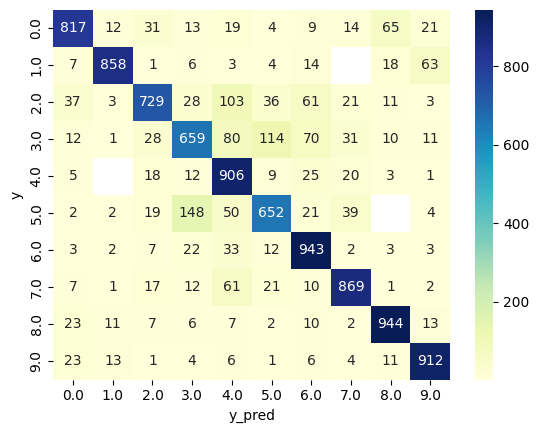

In [525]:
fig, ax = plt.subplots()
sns.heatmap(cnn1_confusion_matrix, annot=True, fmt='.0f', cmap='YlGnBu')
plt.savefig('cnn_champion_confusion_matrix.png')

# Convolutional Neural Network

## Model definition

In [579]:
# 1. Define the CNN Architecture
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, conv_layers=3, batch_norm=False, dropout=False):
        super(SimpleCNN, self).__init__()

        print('-'*30)
        print('* Layers:')
        
        channels = 32
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        new_size = calculate_size(input_size = 32, kernel_size = 3, padding = 1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        new_size = calculate_size(input_size = new_size, kernel_size = 2, stride = 2)
        self.dropout1 = nn.Dropout2d(0.2)
        print(f'Layer 1 output: {new_size}*{new_size}, channels: {channels}')

        channels = 64
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        new_size = calculate_size(input_size = new_size, kernel_size = 3, padding = 1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        new_size = calculate_size(input_size = new_size, kernel_size = 2, stride = 2)
        self.dropout2 = nn.Dropout2d(0.2)
        print(f'Layer 2 output: {new_size}*{new_size}, channels: {channels}')

        if conv_layers >= 3:
            channels = 128
            self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
            new_size = calculate_size(input_size = new_size, kernel_size = 3, padding = 1)
            self.bn3 = nn.BatchNorm2d(128)
            self.relu3 = nn.ReLU()
            self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
            new_size = calculate_size(input_size = new_size, kernel_size = 2, stride = 2)
            #self.dropout3 = nn.Dropout(0.2 if conv_layers == 4 else 0.5)
            self.dropout3 = nn.Dropout2d(0.2)
            print(f'Layer 3 output: {new_size}*{new_size}, channels: {channels}')

            if conv_layers == 4:
                channels = 256
                self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
                new_size = calculate_size(input_size = new_size, kernel_size = 3, padding = 1)
                self.bn4 = nn.BatchNorm2d(256)
                self.relu4 = nn.ReLU()
                self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
                new_size = calculate_size(input_size = new_size, kernel_size = 2, stride = 2)
                self.dropout4 = nn.Dropout2d(0.2)
                print(f'Layer 4 output: {new_size}*{new_size}, channels: {channels}')

        print(f'Linear is {new_size*new_size*channels} to 128')
        self.fc1 = nn.Linear(int(new_size*new_size*channels), 128)
        self.relu_fc1 = nn.ReLU()
        print(f'Linear is 128 to {num_classes}')
        self.fc2 = nn.Linear(128, num_classes)
        self.sigmoid_fc2 = nn.Sigmoid()
        self.dropout5 = nn.Dropout(0.4)

        self.batch_norm = batch_norm
        self.conv_layers = conv_layers
        self.dropout = dropout
        self.new_size = int(new_size)
        self.channels = int(channels)

        print('* Parameters:')
        print(f'Convolutional layers: {self.conv_layers}')
        print(f'Dropout: {self.dropout}')
        print(f'Batch normalization: {self.batch_norm}')
        print(f'Final image size before Linear FC: {self.new_size}')
        print(f'Final channels before Linear FC: {self.channels}')

    def forward(self, x):
        
        x = self.conv1(x)
        x = (self.bn1(x) if self.batch_norm else x)
        x = self.pool1(self.relu1(x))
        x = (self.dropout1(x) if self.dropout else x)

        x = self.conv2(x)
        x = (self.bn2(x) if self.batch_norm else x)
        x = self.pool2(self.relu2(x))
        x = (self.dropout2(x) if self.dropout else x)

        if self.conv_layers >= 3:
            x = self.conv3(x)
            x = (self.bn3(x) if self.batch_norm else x)
            x = self.pool3(self.relu3(x))
            x = (self.dropout3(x) if self.dropout else x)

            if self.conv_layers == 4:
                x = self.conv4(x)
                x = (self.bn4(x) if self.batch_norm else x)
                x = self.pool4(self.relu4(x))
                x = (self.dropout4(x) if self.dropout else x)

        x = x.view(-1, self.new_size * self.new_size * self.channels) # Flatten the output for the fully connected layer
        x = self.fc1(x)
        x = self.relu_fc1(x)
        x = (self.dropout5(x) if self.dropout else x)
        x = self.fc2(x)
        x = self.sigmoid_fc2(x)
        return x

## Training 4 model variations on GPU

### Train code

In [580]:
models_new = {'cnn_3L': SimpleCNN(num_classes=10, conv_layers=3, batch_norm=False, dropout=False),
          'cnn_3L_bn_do': SimpleCNN(num_classes=10, conv_layers=3, batch_norm=True, dropout=True),
          'cnn_4L': SimpleCNN(num_classes=10, conv_layers=4, batch_norm=False, dropout=False),
          'cnn_4L_bn_do': SimpleCNN(num_classes=10, conv_layers=4, batch_norm=True, dropout=True)}

------------------------------
* Layers:
Layer 1 output: 16.0*16.0, channels: 32
Layer 2 output: 8.0*8.0, channels: 64
Layer 3 output: 4.0*4.0, channels: 128
Linear is 2048.0 to 128
Linear is 128 to 10
* Parameters:
Convolutional layers: 3
Dropout: False
Batch normalization: False
Final image size before Linear FC: 4
Final channels before Linear FC: 128
------------------------------
* Layers:
Layer 1 output: 16.0*16.0, channels: 32
Layer 2 output: 8.0*8.0, channels: 64
Layer 3 output: 4.0*4.0, channels: 128
Linear is 2048.0 to 128
Linear is 128 to 10
* Parameters:
Convolutional layers: 3
Dropout: True
Batch normalization: True
Final image size before Linear FC: 4
Final channels before Linear FC: 128
------------------------------
* Layers:
Layer 1 output: 16.0*16.0, channels: 32
Layer 2 output: 8.0*8.0, channels: 64
Layer 3 output: 4.0*4.0, channels: 128
Layer 4 output: 2.0*2.0, channels: 256
Linear is 1024.0 to 128
Linear is 128 to 10
* Parameters:
Convolutional layers: 4
Dropout: Fa

In [581]:
grid_results_with_activations_do2d = {}

for model_name in models_new.keys():
    results = {}

    print(f'------- Loading model {model_name}')
    model = models_new[model_name]

    criterion = nn.CrossEntropyLoss() 
    optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimization

    (trained_model, 
     train_losses, 
     mini_batch_losses,
     train_accuracies, 
     val_accuracies, 
     epoch_times, 
     train_time_gpu) = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)


    results['model'] = trained_model
    results['losses'] = train_losses
    results['mini_batch_losses'] = mini_batch_losses
    results['train_accuracies'] = train_accuracies
    results['val_accuracies'] = val_accuracies
    results['epoch_times'] = epoch_times
    results['train_time'] = train_time_gpu

    grid_results_with_activations_do2d[model_name] = results

------- Loading model cnn_3L
Begin training on cuda:0
Epoch 1, Loss: 1.987, Accuracy: 35.78%, Validation accuracy: 43.89%,, Time: 60s
Epoch 2, Loss: 1.867, Accuracy: 47.26%, Validation accuracy: 49.73%,, Time: 38s
Epoch 3, Loss: 1.819, Accuracy: 53.48%, Validation accuracy: 54.43%,, Time: 38s
Epoch 4, Loss: 1.787, Accuracy: 57.51%, Validation accuracy: 58.94%,, Time: 40s
Epoch 5, Loss: 1.757, Accuracy: 60.88%, Validation accuracy: 62.21%,, Time: 39s
Epoch 6, Loss: 1.735, Accuracy: 63.73%, Validation accuracy: 63.72%,, Time: 38s
Epoch 7, Loss: 1.718, Accuracy: 65.89%, Validation accuracy: 63.46%,, Time: 40s
Epoch 8, Loss: 1.704, Accuracy: 67.54%, Validation accuracy: 66.97%,, Time: 40s
Epoch 9, Loss: 1.690, Accuracy: 69.52%, Validation accuracy: 67.22%,, Time: 40s
Epoch 10, Loss: 1.677, Accuracy: 71.14%, Validation accuracy: 69.45%,, Time: 40s
Epoch 11, Loss: 1.668, Accuracy: 72.25%, Validation accuracy: 69.32%,, Time: 39s
Epoch 12, Loss: 1.659, Accuracy: 73.18%, Validation accuracy: 70

In [582]:
with open('grid_results_with_activations_do2d.pickle', 'wb') as file:
    pickle.dump(grid_results_with_activations_do2d, file)

### Training on CPU for comparison

In [548]:
models_cpu = {'cnn_3L': SimpleCNN(num_classes=10, conv_layers=3, batch_norm=False, dropout=False),
          'cnn_3L_bn_do': SimpleCNN(num_classes=10, conv_layers=3, batch_norm=True, dropout=True),
          'cnn_4L': SimpleCNN(num_classes=10, conv_layers=4, batch_norm=False, dropout=False),
          'cnn_4L_bn_do': SimpleCNN(num_classes=10, conv_layers=4, batch_norm=True, dropout=True)}

------------------------------
* Layers:
Layer 1 output: 16.0*16.0, channels: 32
Layer 2 output: 8.0*8.0, channels: 64
Layer 3 output: 4.0*4.0, channels: 128
Linear is 2048.0 to 128
Linear is 128 to 10
* Parameters:
Convolutional layers: 3
Dropout: False
Batch normalization: False
Final image size before Linear FC: 4
Final channels before Linear FC: 128
------------------------------
* Layers:
Layer 1 output: 16.0*16.0, channels: 32
Layer 2 output: 8.0*8.0, channels: 64
Layer 3 output: 4.0*4.0, channels: 128
Linear is 2048.0 to 128
Linear is 128 to 10
* Parameters:
Convolutional layers: 3
Dropout: True
Batch normalization: True
Final image size before Linear FC: 4
Final channels before Linear FC: 128
------------------------------
* Layers:
Layer 1 output: 16.0*16.0, channels: 32
Layer 2 output: 8.0*8.0, channels: 64
Layer 3 output: 4.0*4.0, channels: 128
Layer 4 output: 2.0*2.0, channels: 256
Linear is 1024.0 to 128
Linear is 128 to 10
* Parameters:
Convolutional layers: 4
Dropout: Fa

In [551]:
grid_results_cpu = {}

num_epochs = 50

for model_name in models_cpu.keys():
    results = {}

    print(f'------- Loading model {model_name}')
    model = models_cpu[model_name]

    criterion = nn.CrossEntropyLoss() 
    optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimization

    (trained_model, 
     train_losses, 
     mini_batch_losses,
     train_accuracies, 
     val_accuracies, 
     epoch_times, 
     train_time_gpu) = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device='cpu')


    results['model'] = trained_model
    results['losses'] = train_losses
    results['mini_batch_losses'] = mini_batch_losses
    results['train_accuracies'] = train_accuracies
    results['val_accuracies'] = val_accuracies
    results['epoch_times'] = epoch_times
    results['train_time'] = train_time_gpu

    grid_results_cpu[model_name] = results

------- Loading model cnn_3L
Begin training on cpu
Epoch 1, Loss: 1.745, Accuracy: 62.04%, Validation accuracy: 62.93%,, Time: 80s
Epoch 2, Loss: 1.726, Accuracy: 64.55%, Validation accuracy: 65.26%,, Time: 79s
Epoch 3, Loss: 1.710, Accuracy: 66.46%, Validation accuracy: 65.54%,, Time: 80s
Epoch 4, Loss: 1.698, Accuracy: 68.42%, Validation accuracy: 65.20%,, Time: 78s
Epoch 5, Loss: 1.688, Accuracy: 69.59%, Validation accuracy: 68.87%,, Time: 78s
Epoch 6, Loss: 1.674, Accuracy: 71.25%, Validation accuracy: 68.56%,, Time: 79s
Epoch 7, Loss: 1.664, Accuracy: 72.49%, Validation accuracy: 70.18%,, Time: 78s
Epoch 8, Loss: 1.658, Accuracy: 73.24%, Validation accuracy: 70.62%,, Time: 78s
Epoch 9, Loss: 1.649, Accuracy: 74.48%, Validation accuracy: 72.35%,, Time: 78s
Epoch 10, Loss: 1.643, Accuracy: 75.11%, Validation accuracy: 71.52%,, Time: 78s
Epoch 11, Loss: 1.637, Accuracy: 75.86%, Validation accuracy: 72.96%,, Time: 78s
Epoch 12, Loss: 1.630, Accuracy: 76.50%, Validation accuracy: 72.94

In [277]:
import pickle

with open('model_performance_final_cpu.pickle', 'wb') as file:
    pickle.dump(grid_results_cpu, file)

### First iteration without activation functions on dense and output layer

In [502]:
import pickle
with open('model_performance_before_activations.pickle', 'rb') as file:
    grid_results = pickle.load(file)

In [503]:
new_dict = switch_dictionary(grid_results)

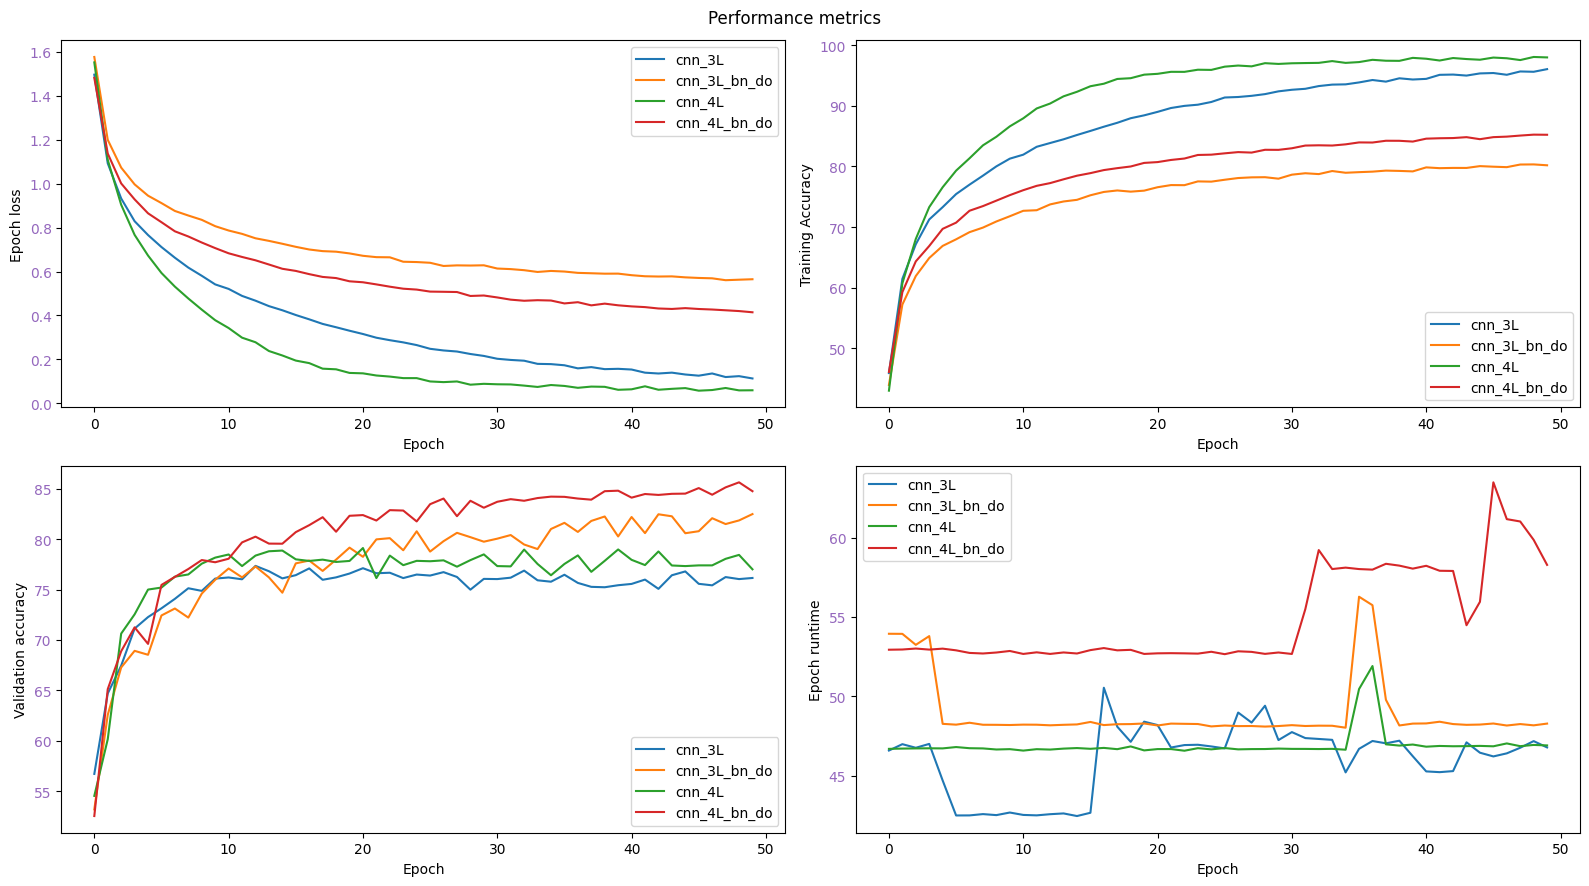

In [504]:
generate_epoch_plots(new_dict, 'cnn_m1_performance.png')

0.001533242641016841 4.24720573425293


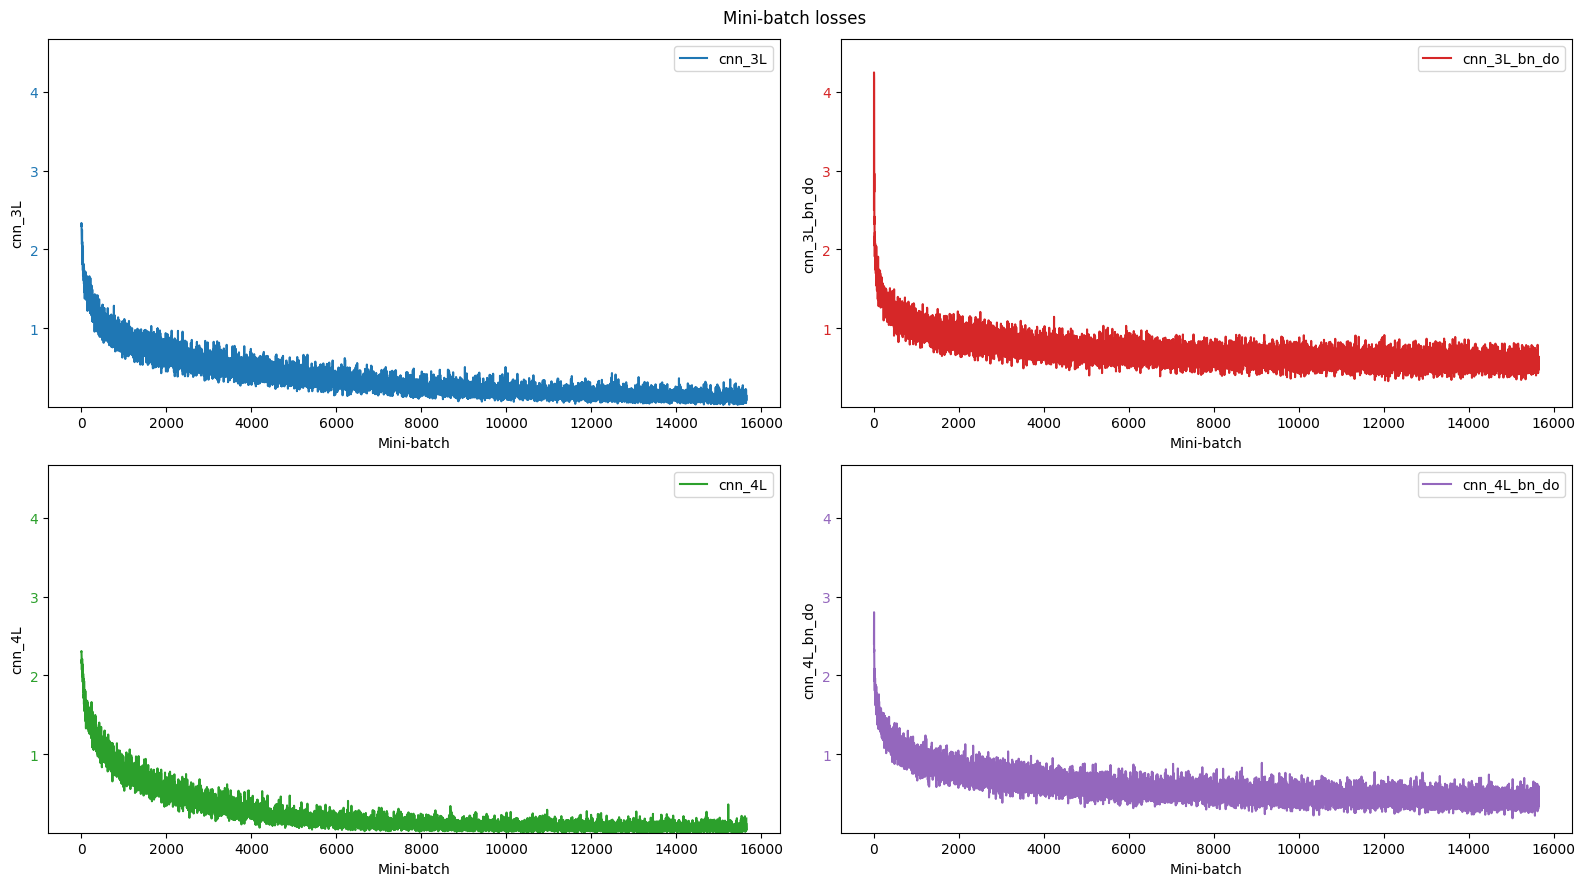

In [505]:
generate_mini_batch_plot(new_dict, 'cnn_m1_mini_batch_losses.png')

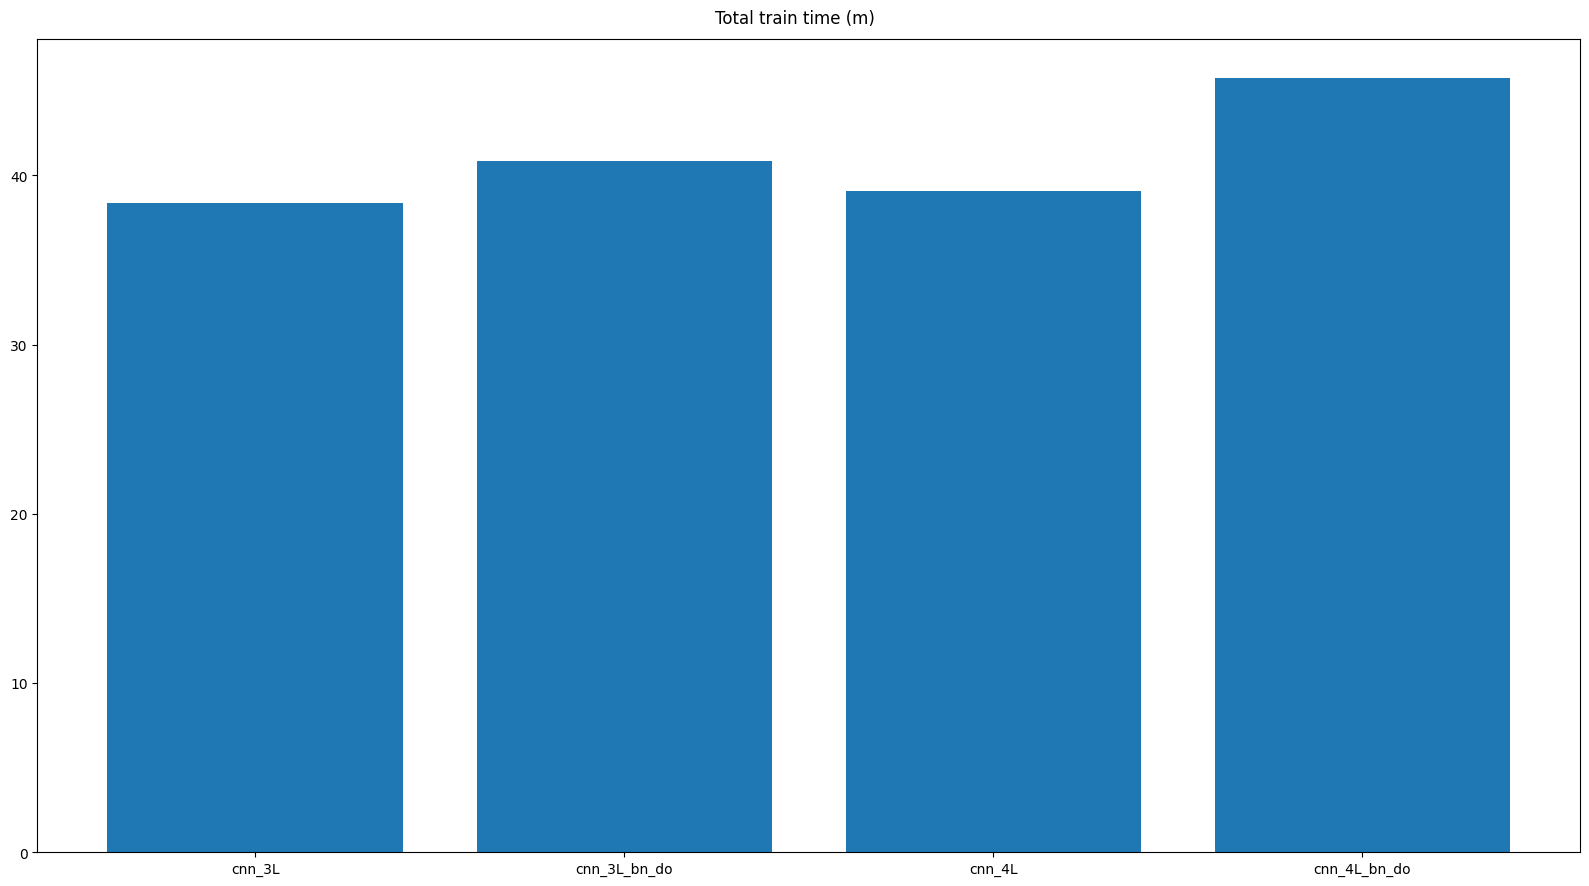

In [506]:
generate_total_runtime_plot(new_dict, 'cnn_m1_train_times.png')

### Second iteration adding ReLU activation for dense layer, plus softmax for output layer

In [507]:
with open('model_performance_after_activations.pickle_softmax', 'rb') as file:
    grid_results_with_activations_softmax = pickle.load(file)

In [508]:
new_dict = switch_dictionary(grid_results_with_activations_softmax)

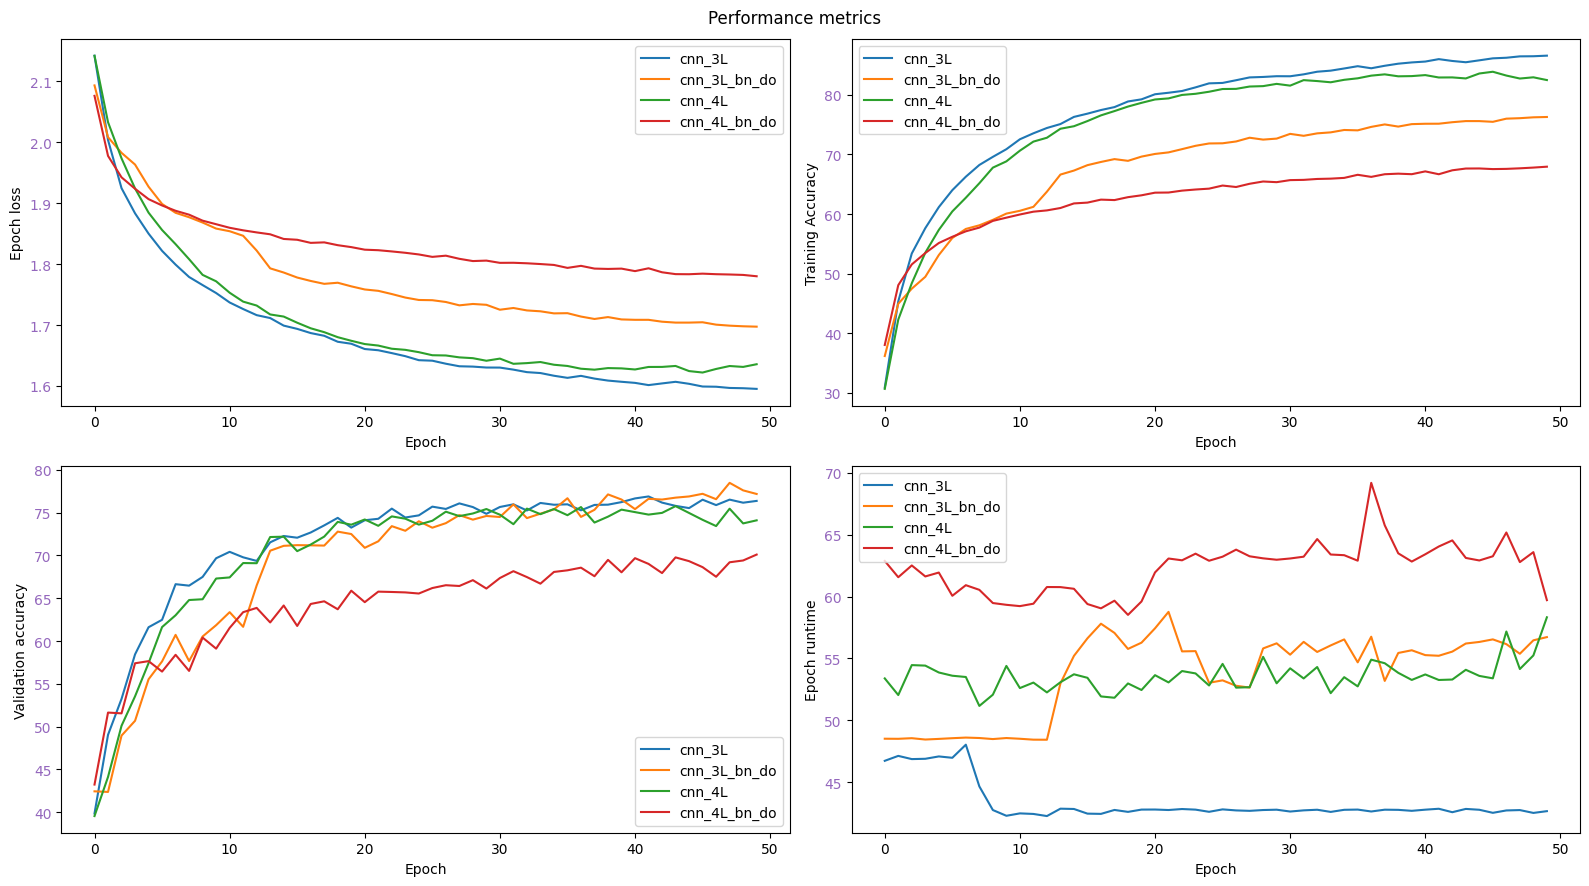

In [509]:
generate_epoch_plots(new_dict, 'cnn_m2_performance.png')

1.5021321773529053 2.3168139457702637


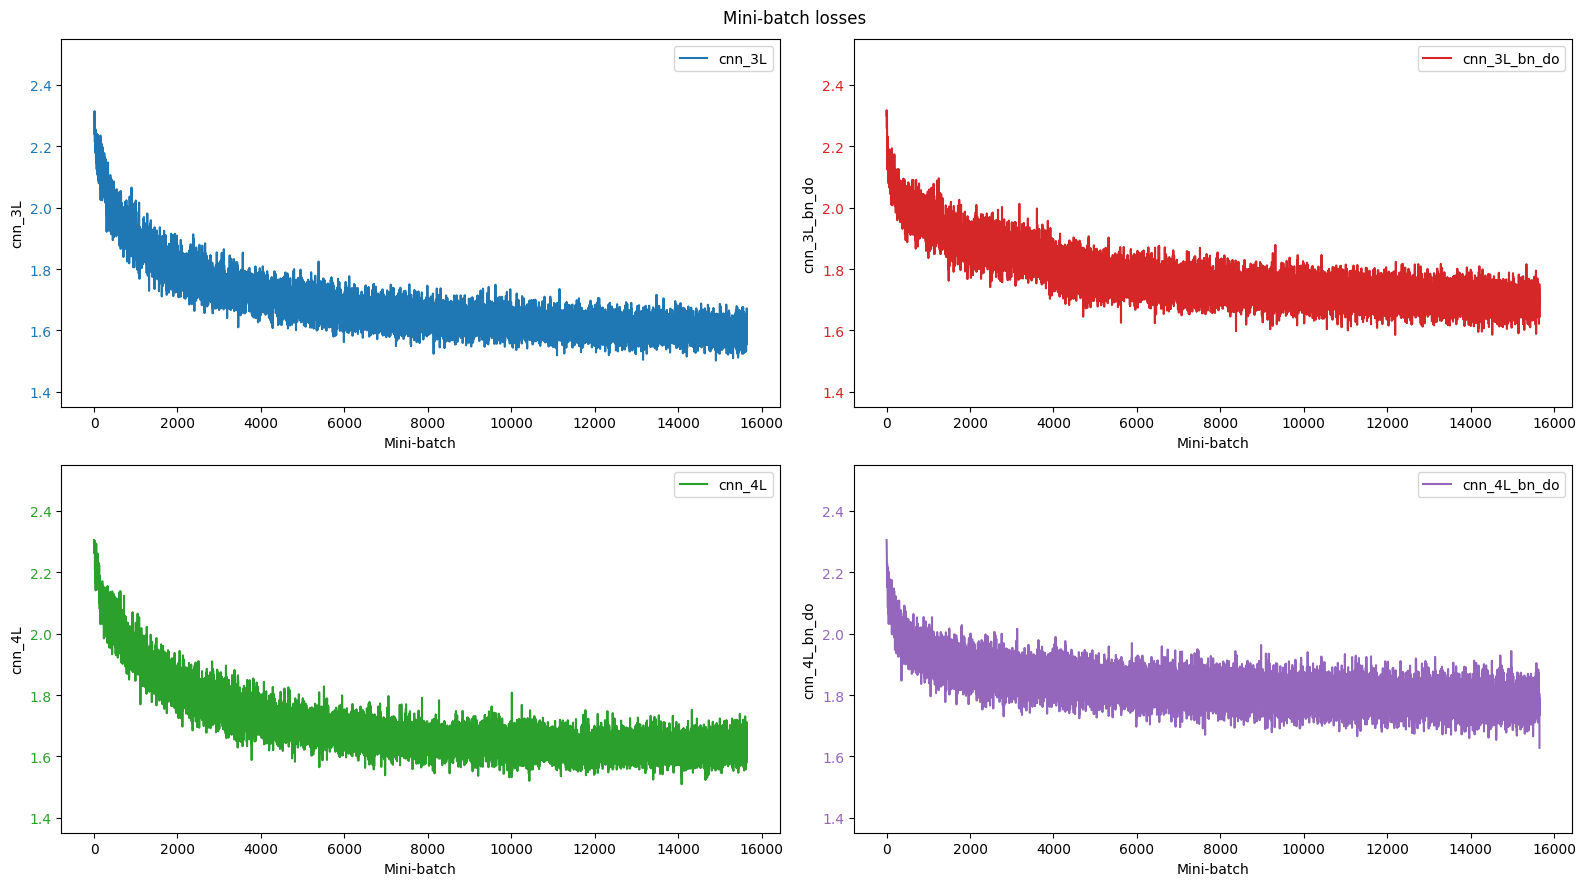

In [510]:
generate_mini_batch_plot(new_dict, 'cnn_m2_mini_batch_losses.png')

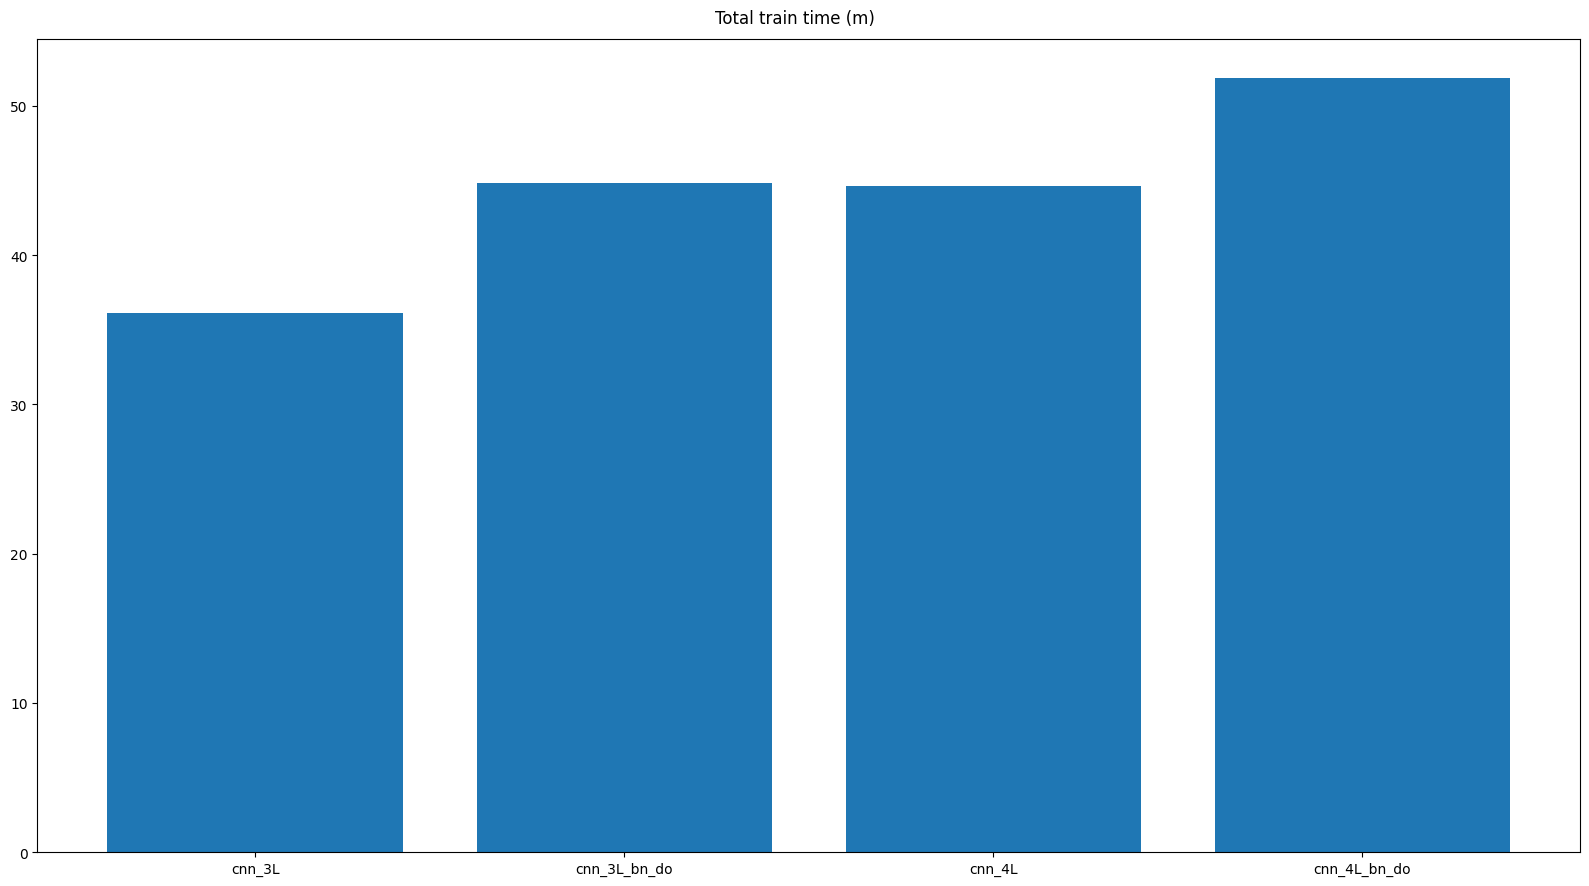

In [511]:
generate_total_runtime_plot(new_dict, 'cnn_m2_train_times.png')

### Third iteration substituting softmax function for sigmoid activation

In [536]:
with open('model_performance_after_activations.pickle_sigmoid', 'rb') as file:
    grid_results_with_activations_sigmoid = pickle.load(file)

In [537]:
new_dict = switch_dictionary(grid_results_with_activations_sigmoid)

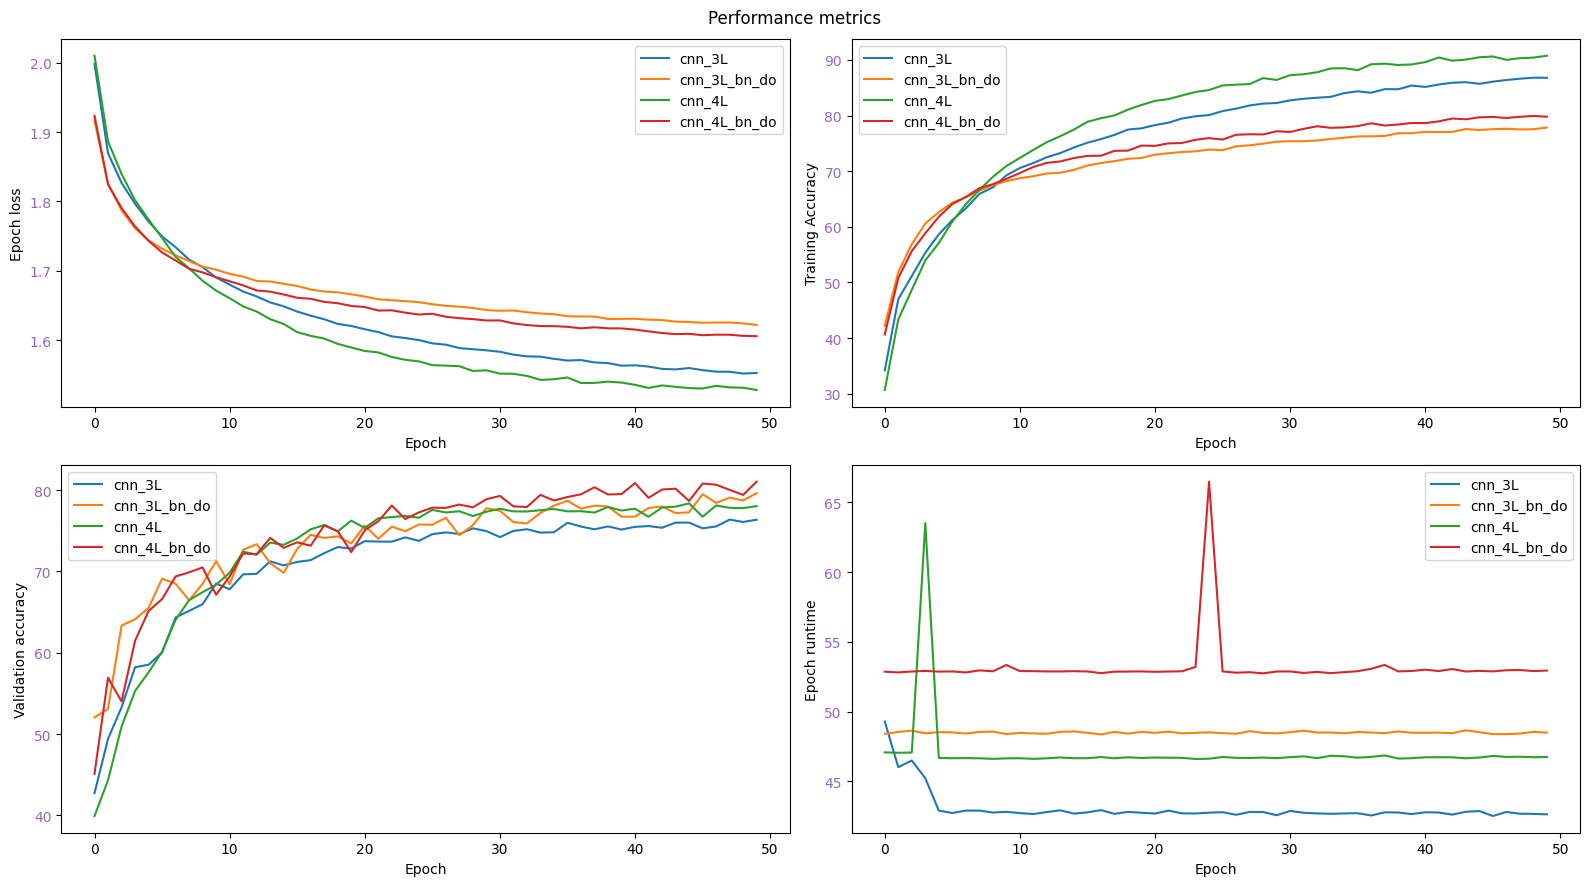

In [538]:
generate_epoch_plots(new_dict, 'cnn_m3_performance.png')

1.4801199436187744 2.3099944591522217


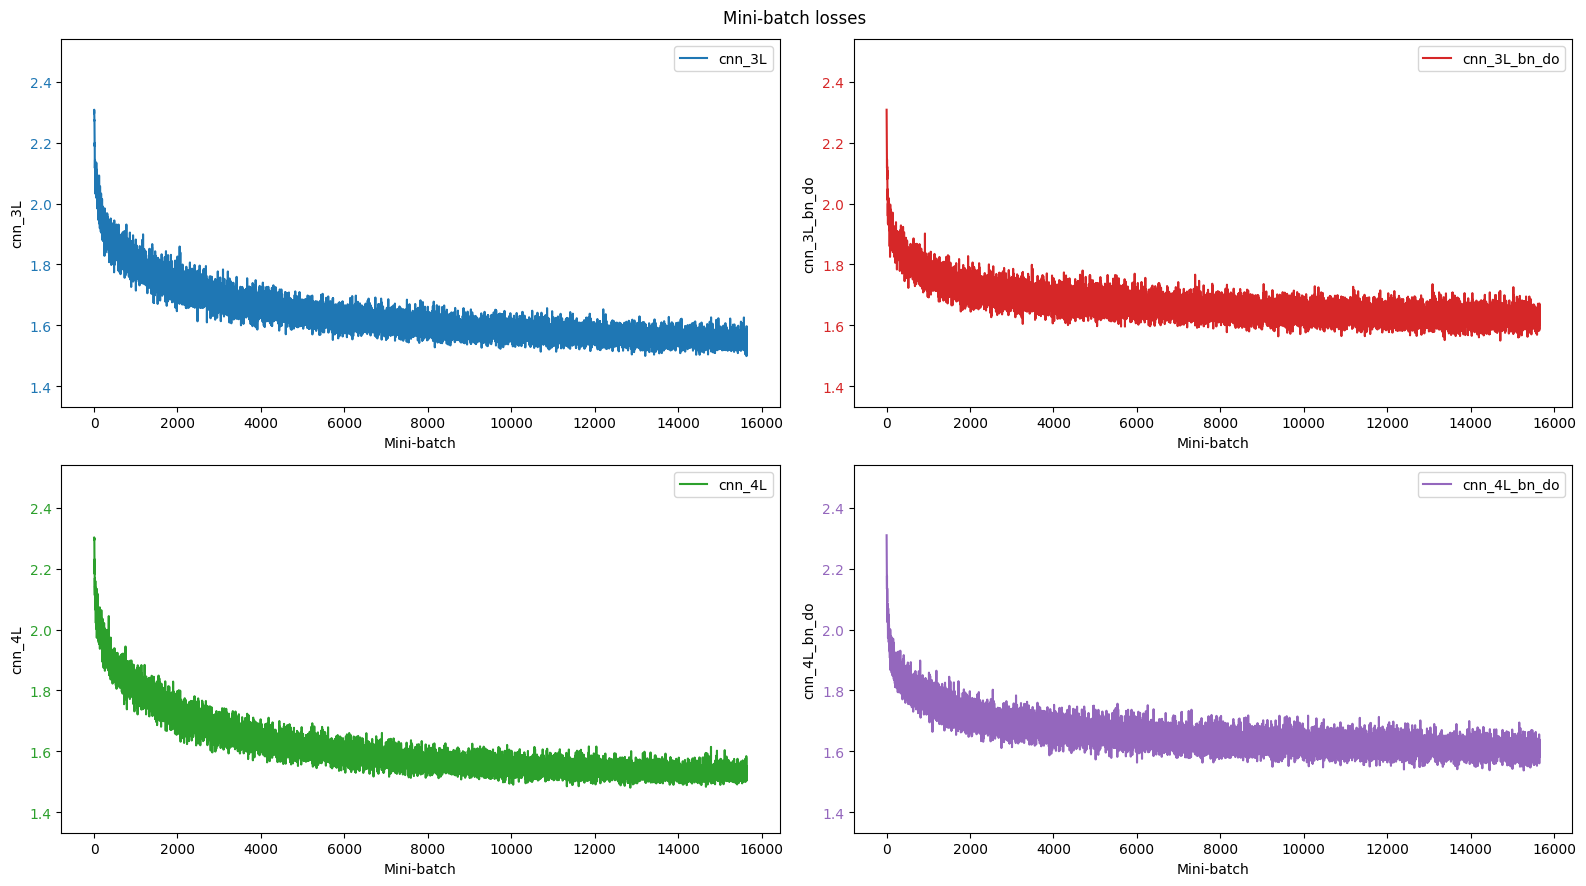

In [539]:
generate_mini_batch_plot(new_dict, 'cnn_m3_mini_batch_losses.png')

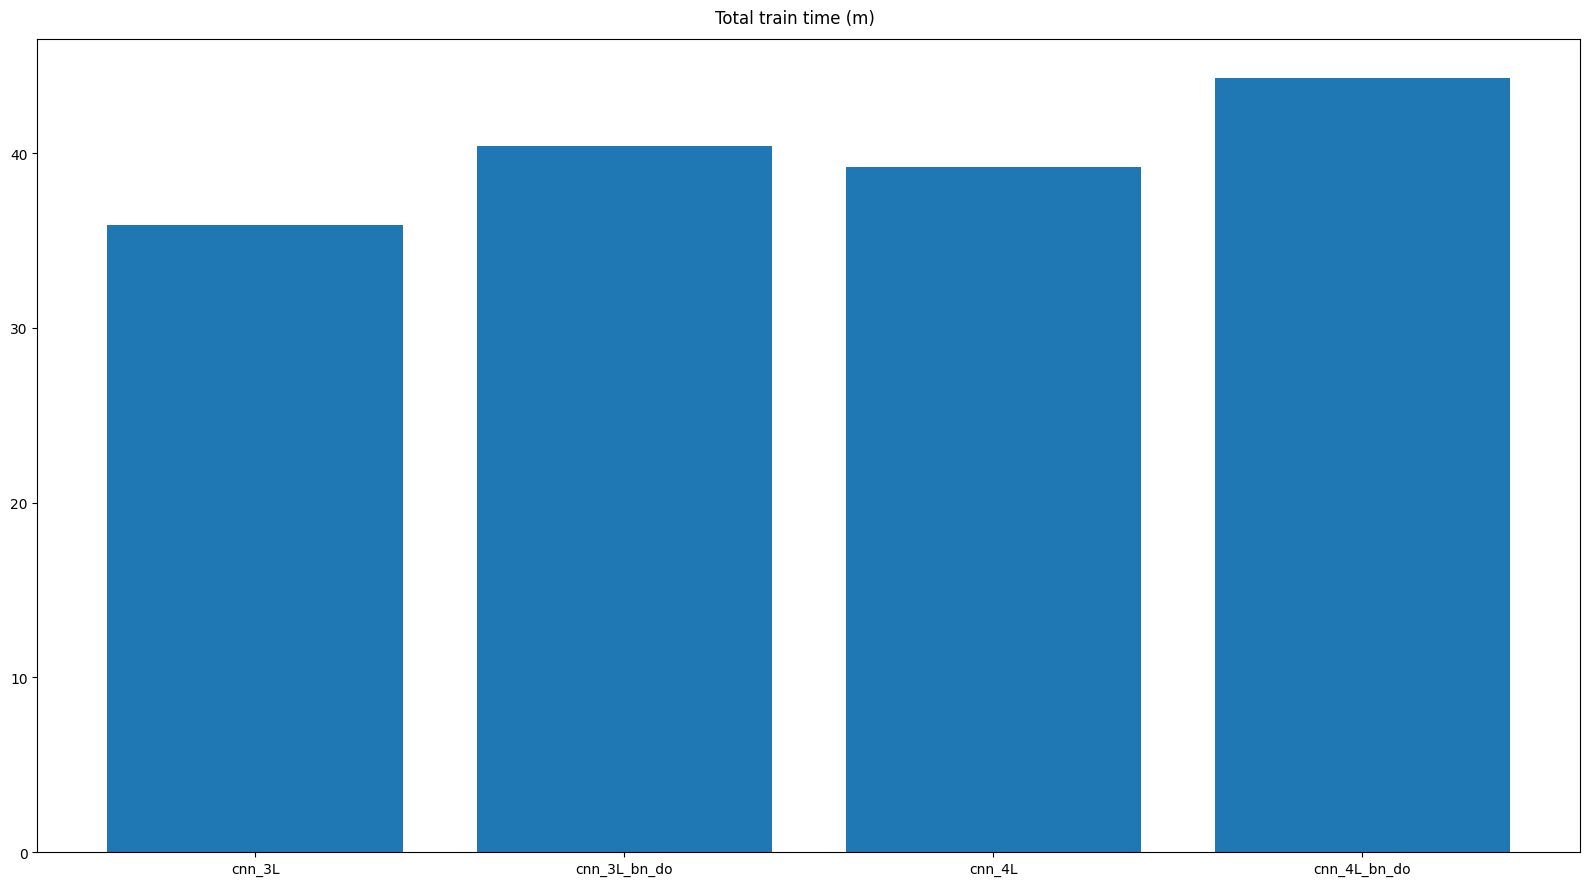

In [540]:
generate_total_runtime_plot(new_dict, 'cnn_m3_train_times.png')

### Fourth iteration adding a dropout stage in one of the dense layers

In [531]:
with open('model_performance_after_activations.pickle_sigmoid_dropout', 'rb') as file:
    grid_results_with_activations_sigmoid_dropout = pickle.load(file)

In [532]:
new_dict = switch_dictionary(grid_results_with_activations_sigmoid_dropout)

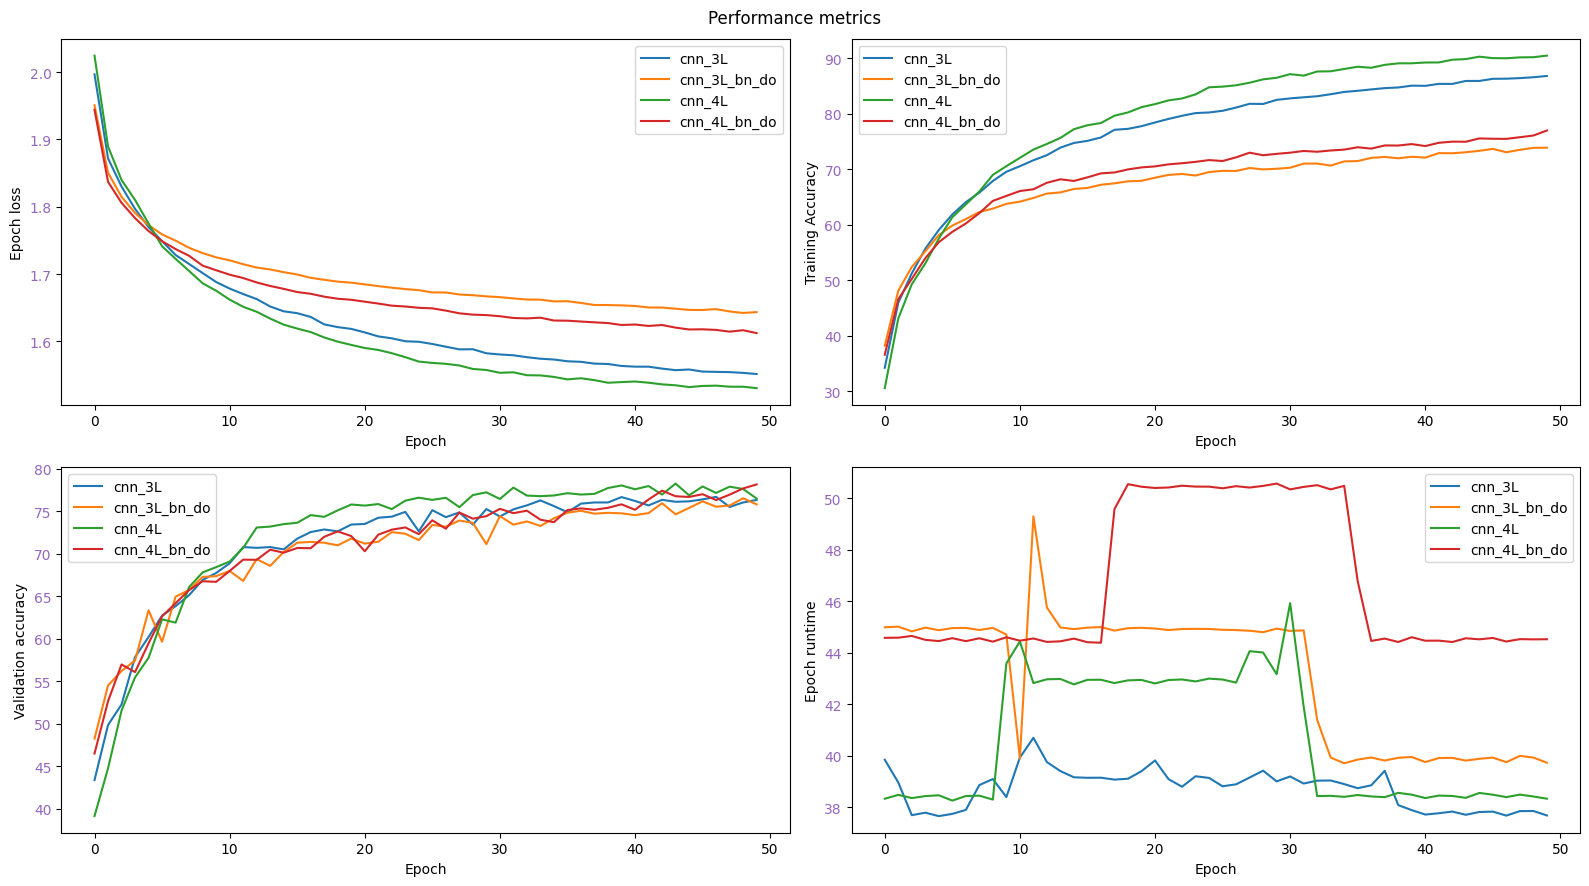

In [533]:
generate_epoch_plots(new_dict, 'cnn_m4_performance.png')

1.4840580224990845 2.3269519805908203


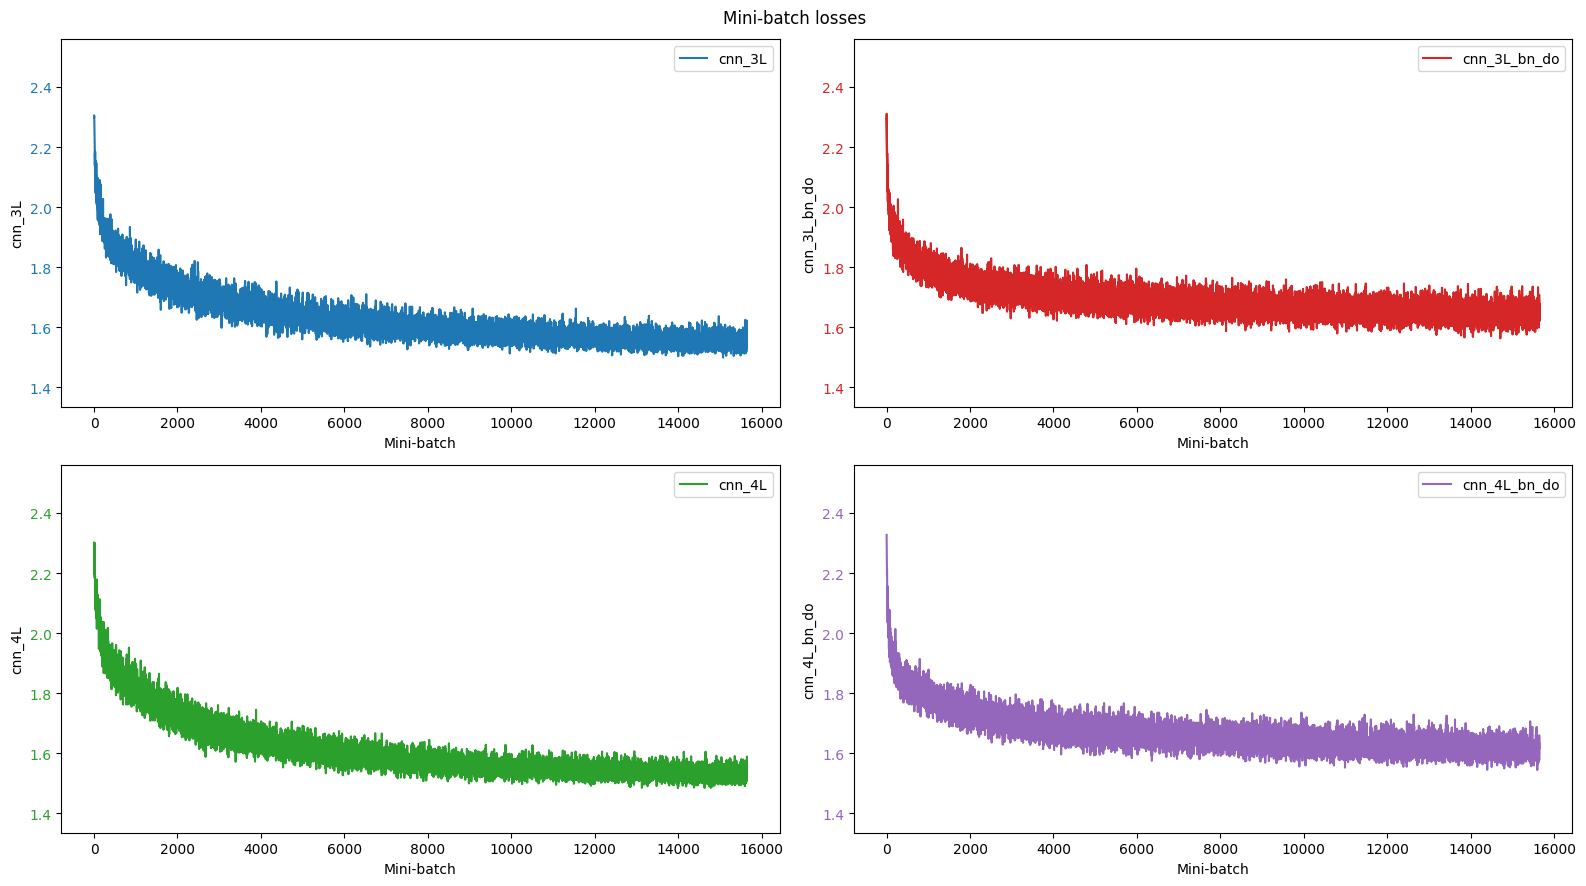

In [534]:
generate_mini_batch_plot(new_dict, 'cnn_m4_mini_batch_losses.png')

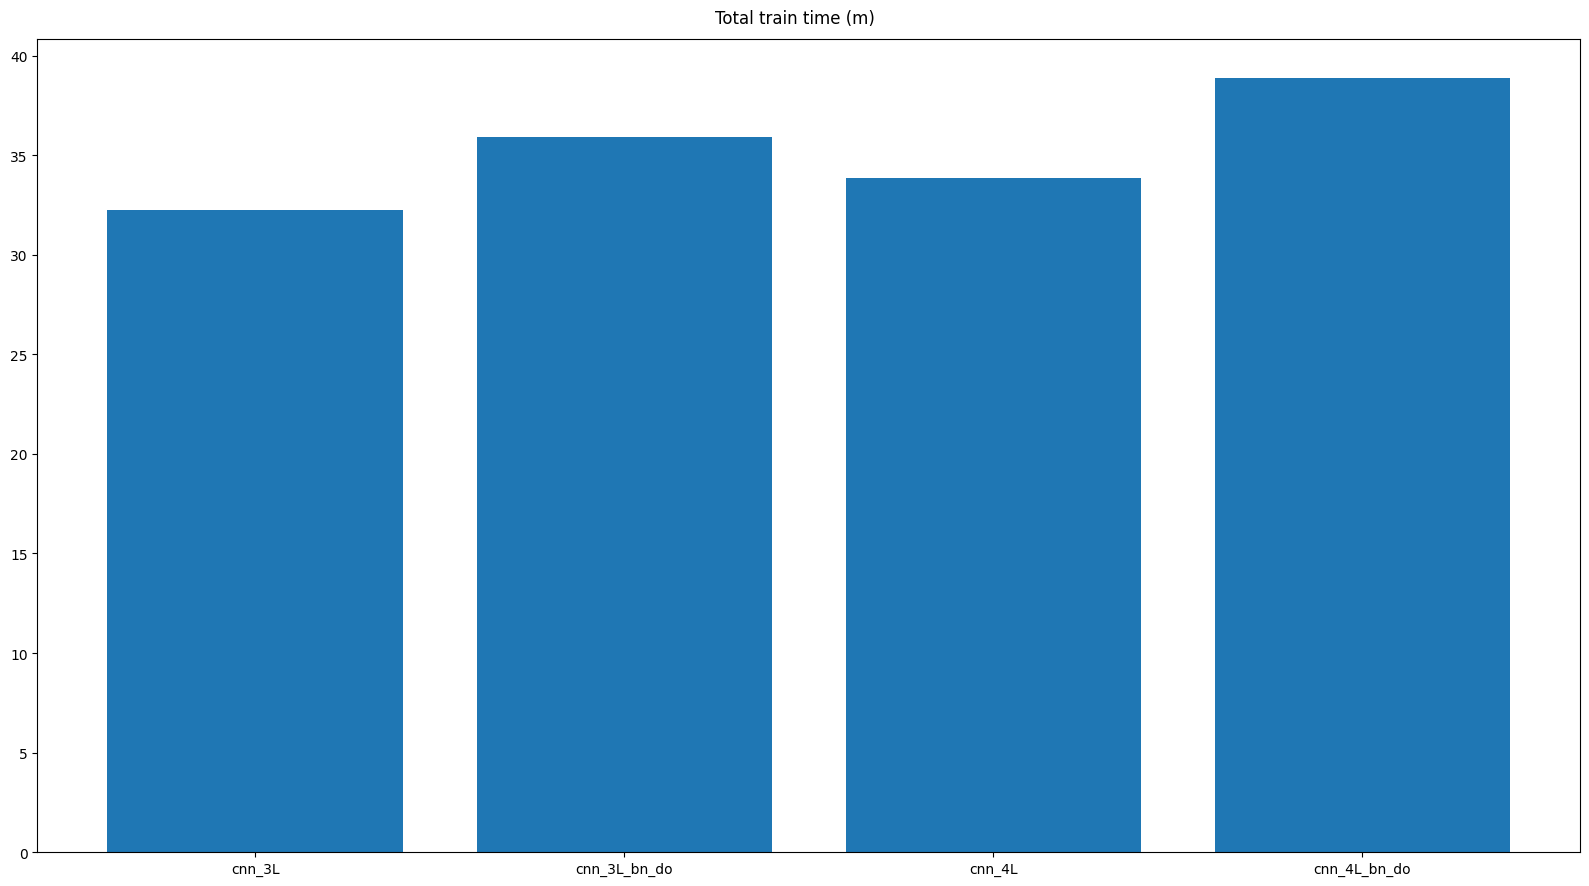

In [535]:
generate_total_runtime_plot(new_dict, 'cnn_m4_train_times.png')

### Fifth iteration switching dropout to dropout2d in convolutional layers

In [531]:
with open('grid_results_with_activations_do2d.pickle', 'rb') as file:
    grid_results_with_activations_do2d = pickle.load(file)

In [583]:
new_dict = switch_dictionary(grid_results_with_activations_do2d)

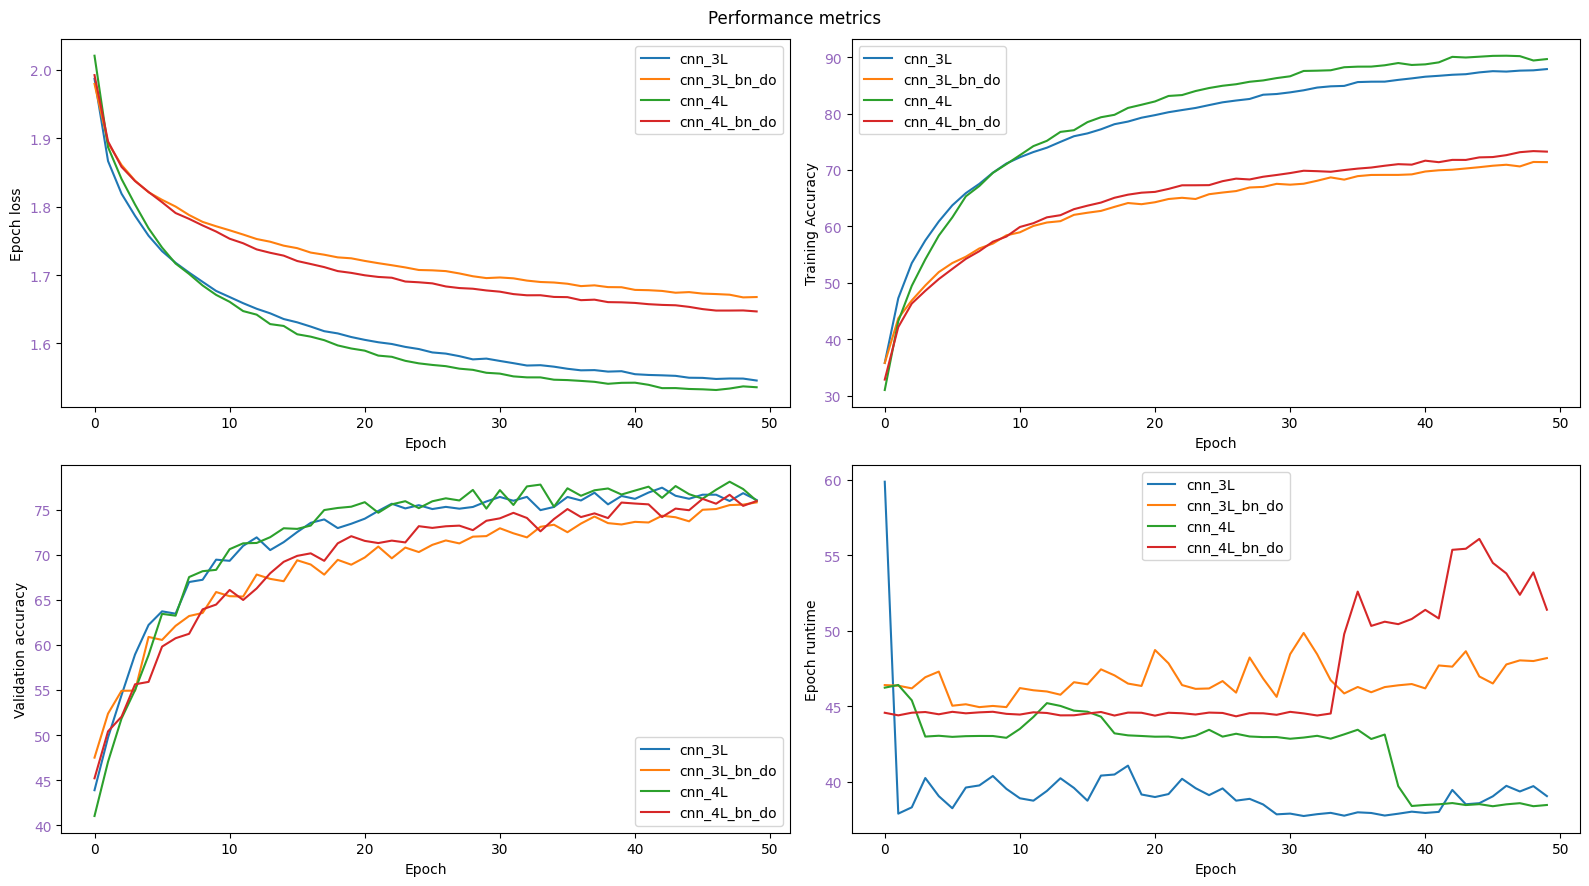

In [584]:
generate_epoch_plots(new_dict, 'cnn_m4_performance.png')

1.4782087802886963 2.3149662017822266


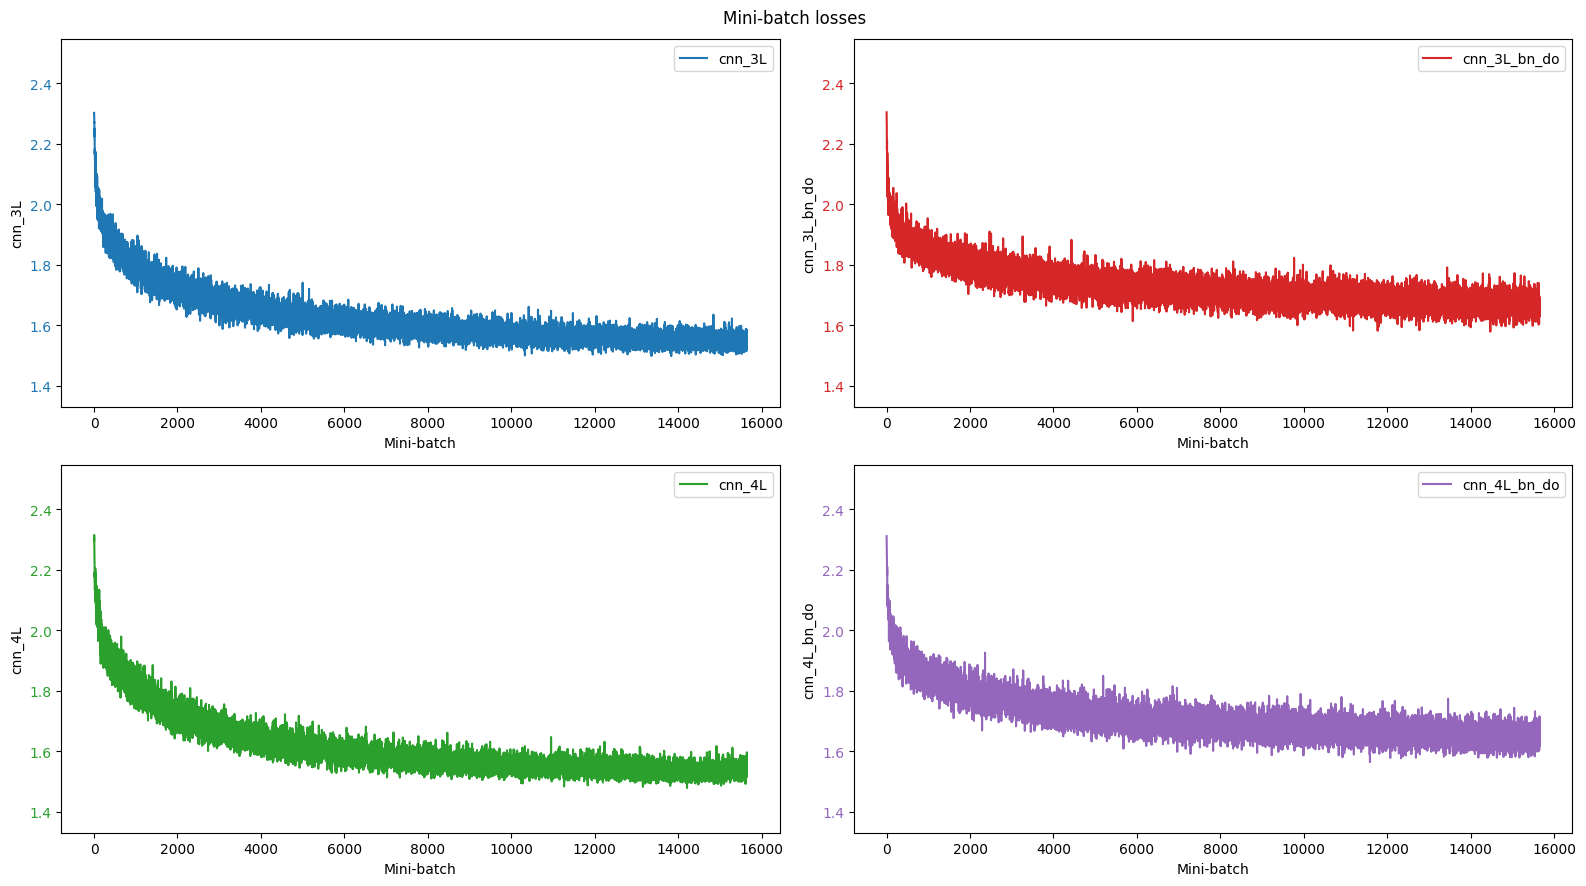

In [585]:
generate_mini_batch_plot(new_dict, 'cnn_m4_mini_batch_losses.png')

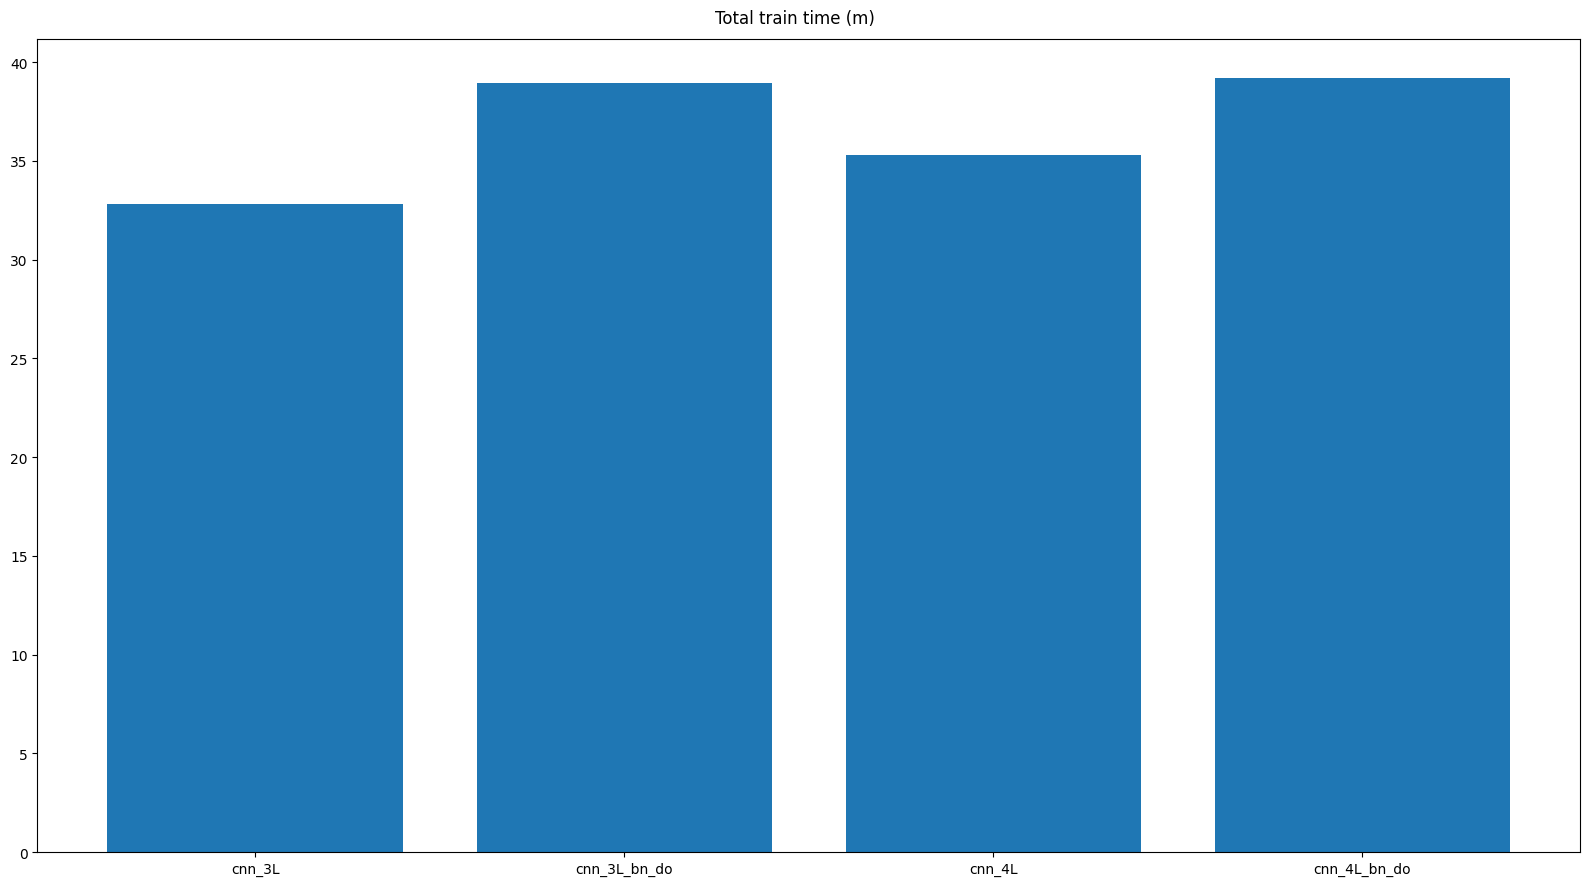

In [586]:
generate_total_runtime_plot(new_dict, 'cnn_m4_train_times.png')

## Comparing models

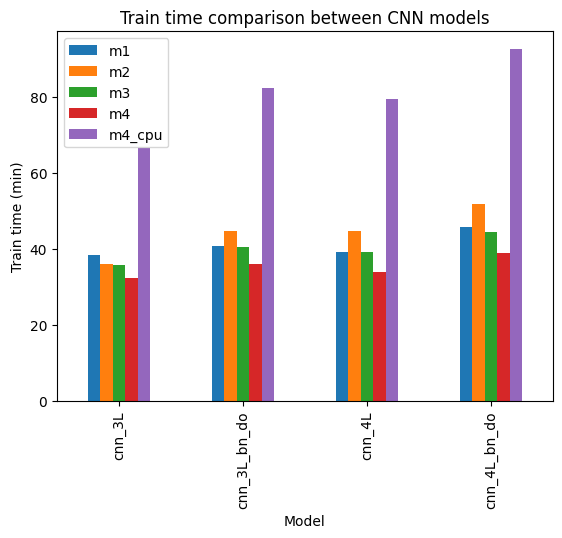

In [636]:
grid_resuls_r = switch_dictionary(grid_results)
grid_results_with_activations_softmax_r = switch_dictionary(grid_results_with_activations_softmax)
grid_results_with_activations_sigmoid_r = switch_dictionary(grid_results_with_activations_sigmoid)
grid_results_with_activations_sigmoid_dropout_r = switch_dictionary(grid_results_with_activations_sigmoid_dropout)
grid_results_cpu_r = switch_dictionary(grid_results_cpu)

m1 = pd.DataFrame(grid_resuls_r['train_time'].values(), grid_resuls_r['train_time'].keys()).rename({0:'m1'},axis=1)
m2 = pd.DataFrame(grid_results_with_activations_softmax_r['train_time'].values(), grid_results_with_activations_softmax_r['train_time'].keys()).rename({0:'m2'}, axis=1)
m3 = pd.DataFrame(grid_results_with_activations_sigmoid_r['train_time'].values(), grid_results_with_activations_sigmoid_r['train_time'].keys()).rename({0:'m3'}, axis=1)
m4 = pd.DataFrame(grid_results_with_activations_sigmoid_dropout_r['train_time'].values(), grid_results_with_activations_sigmoid_dropout_r['train_time'].keys()).rename({0:'m4'}, axis=1)
m5 = pd.DataFrame(grid_results_cpu_r['train_time'].values(), grid_results_cpu_r['train_time'].keys()).rename({0:'m4_cpu'}, axis=1)


comparison = m1.join(m2).join(m3).join(m4).join(m5)
comparison = comparison / 60
#comparison = comparison.rename({'cnn_3L': 'mlp_3L', 'cnn_3L_do':'mlp_3L_do'},axis=0)
comparison = comparison.reset_index().rename({'index':'model'}, axis=1)

comparison.plot(x='model', y=['m1', 'm2', 'm3', 'm4','m4_cpu'], kind='bar')
plt.title('Train time comparison between CNN models')
plt.ylabel('Train time (min)')
plt.xlabel('Model')
plt.savefig('cnn_train_time_comparison.png')
plt.show()

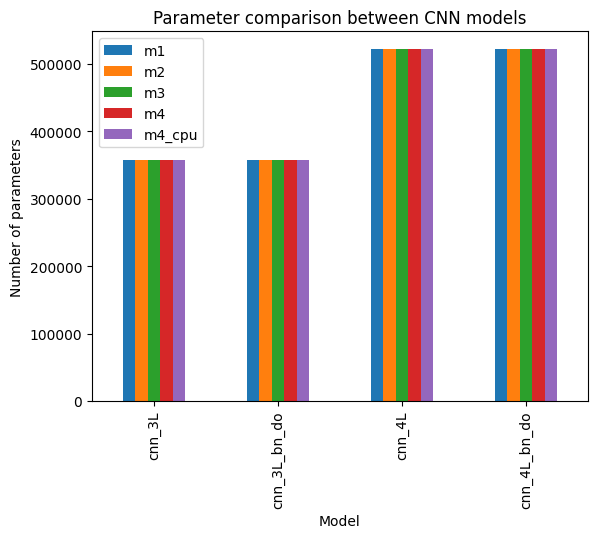

In [637]:
grid_resuls_r = switch_dictionary(grid_results)
grid_results_with_activations_softmax_r = switch_dictionary(grid_results_with_activations_softmax)
grid_results_with_activations_sigmoid_r = switch_dictionary(grid_results_with_activations_sigmoid)
grid_results_with_activations_sigmoid_dropout_r = switch_dictionary(grid_results_with_activations_sigmoid_dropout)
grid_results_cpu_r = switch_dictionary(grid_results_cpu)

m1 = pd.DataFrame([sum(p.numel() for p in x.parameters()) for x in grid_resuls_r['model'].values()], grid_resuls_r['train_time'].keys()).rename({0:'m1'},axis=1)
m2 = pd.DataFrame([sum(p.numel() for p in x.parameters()) for x in grid_results_with_activations_softmax_r['model'].values()], grid_results_with_activations_softmax_r['train_time'].keys()).rename({0:'m2'}, axis=1)
m3 = pd.DataFrame([sum(p.numel() for p in x.parameters()) for x in grid_results_with_activations_sigmoid_r['model'].values()], grid_results_with_activations_sigmoid_r['train_time'].keys()).rename({0:'m3'}, axis=1)
m4 = pd.DataFrame([sum(p.numel() for p in x.parameters()) for x in grid_results_with_activations_sigmoid_dropout_r['model'].values()], grid_results_with_activations_sigmoid_dropout_r['train_time'].keys()).rename({0:'m4'}, axis=1)
m5 = pd.DataFrame([sum(p.numel() for p in x.parameters()) for x in grid_results_cpu_r['model'].values()], grid_results_cpu_r['train_time'].keys()).rename({0:'m4_cpu'}, axis=1)


comparison = m1.join(m2).join(m3).join(m4).join(m5)
#comparison = comparison.rename({'cnn_3L': 'mlp_3L', 'cnn_3L_do':'mlp_3L_bn_do'},axis=0)
comparison = comparison.reset_index().rename({'index':'model'}, axis=1)

comparison.plot(x='model', y=['m1', 'm2', 'm3', 'm4','m4_cpu'], kind='bar')
plt.title('Parameter comparison between CNN models')
plt.ylabel('Number of parameters')
plt.xlabel('Model')
plt.savefig('cnn_parameter_comparison.png')
plt.show()

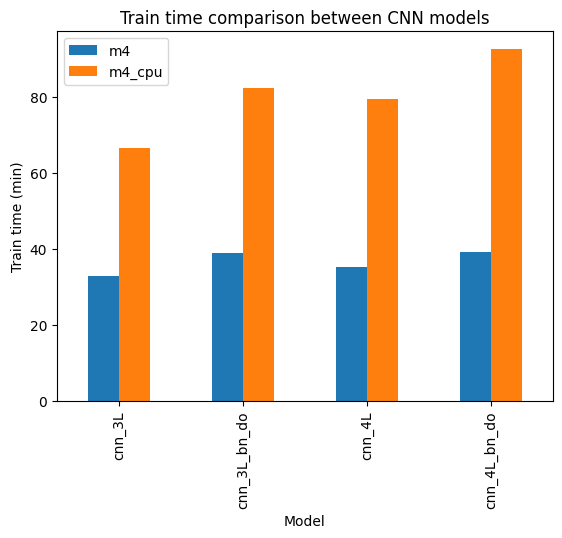

In [638]:
grid_results_with_activations_do2d_r = switch_dictionary(grid_results_with_activations_do2d)
grid_results_cpu_r = switch_dictionary(grid_results_cpu)

m4 = pd.DataFrame(grid_results_with_activations_do2d_r['train_time'].values(), grid_results_with_activations_do2d_r['train_time'].keys()).rename({0:'m4'}, axis=1)
m5 = pd.DataFrame(grid_results_cpu_r['train_time'].values(), grid_results_cpu_r['train_time'].keys()).rename({0:'m4_cpu'}, axis=1)

comparison = m4.join(m5)
comparison = comparison / 60
#comparison = comparison.rename({'cnn_3L': 'mlp_3L', 'cnn_3L_do':'mlp_3L_do'},axis=0)
comparison = comparison.reset_index().rename({'index':'model'}, axis=1)

comparison.plot(x='model', y=['m4','m4_cpu'], kind='bar')
plt.title('Train time comparison between CNN models')
plt.ylabel('Train time (min)')
plt.xlabel('Model')
plt.savefig('cnn_train_time_comparison.png')
plt.show()

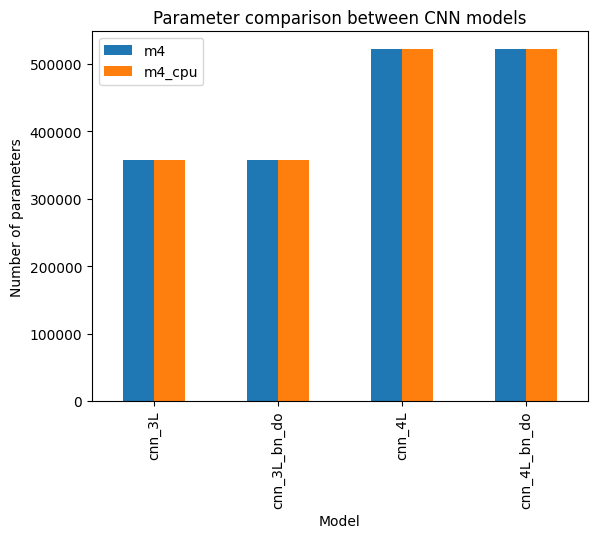

In [639]:

grid_results_with_activations_do2d_r = switch_dictionary(grid_results_with_activations_do2d)
grid_results_cpu_r = switch_dictionary(grid_results_cpu)

m4 = pd.DataFrame(grid_results_with_activations_do2d_r['train_time'].values(), grid_results_with_activations_do2d_r['train_time'].keys()).rename({0:'m4'}, axis=1)
m5 = pd.DataFrame(grid_results_cpu_r['train_time'].values(), grid_results_cpu_r['train_time'].keys()).rename({0:'m4_cpu'}, axis=1)


m4 = pd.DataFrame([sum(p.numel() for p in x.parameters()) for x in grid_results_with_activations_do2d_r['model'].values()], grid_results_with_activations_sigmoid_dropout_r['train_time'].keys()).rename({0:'m4'}, axis=1)
m5 = pd.DataFrame([sum(p.numel() for p in x.parameters()) for x in grid_results_cpu_r['model'].values()], grid_results_cpu_r['train_time'].keys()).rename({0:'m4_cpu'}, axis=1)


comparison = m4.join(m5)
#comparison = comparison.rename({'cnn_3L': 'mlp_3L', 'cnn_3L_do':'mlp_3L_do'},axis=0)
comparison = comparison.reset_index().rename({'index':'model'}, axis=1)

comparison.plot(x='model', y=['m4','m4_cpu'], kind='bar')
plt.title('Parameter comparison between CNN models')
plt.ylabel('Number of parameters')
plt.xlabel('Model')
plt.savefig('cnn_parameter_comparison.png')
plt.show()

## Champion model

After reviewing all data, looks like the most comprehensive model with 50 epocs could be the 4 layer CNN with batch normalization, dropout in all stages and sigmoid output, so it was trained for 100 epocs

### Training 100 epochs

In [589]:
models_only_4L = {'cnn_4L_bn_do': SimpleCNN(num_classes=10, conv_layers=4, batch_norm=True, dropout=True)}

------------------------------
* Layers:
Layer 1 output: 16.0*16.0, channels: 32
Layer 2 output: 8.0*8.0, channels: 64
Layer 3 output: 4.0*4.0, channels: 128
Layer 4 output: 2.0*2.0, channels: 256
Linear is 1024.0 to 128
Linear is 128 to 10
* Parameters:
Convolutional layers: 4
Dropout: True
Batch normalization: True
Final image size before Linear FC: 2
Final channels before Linear FC: 256


In [590]:
grid_results_with_activations_only4L = {}

num_epochs = 100

for model_name in models_only_4L.keys():
    results = {}

    print(f'------- Loading model {model_name}')
    model = models_only_4L[model_name]

    criterion = nn.CrossEntropyLoss() 
    optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimization

    (trained_model, 
     train_losses, 
     mini_batch_losses,
     train_accuracies, 
     val_accuracies, 
     epoch_times, 
     train_time_gpu) = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)


    results['model'] = trained_model
    results['losses'] = train_losses
    results['mini_batch_losses'] = mini_batch_losses
    results['train_accuracies'] = train_accuracies
    results['val_accuracies'] = val_accuracies
    results['epoch_times'] = epoch_times
    results['train_time'] = train_time_gpu

    grid_results_with_activations_only4L[model_name] = results

------- Loading model cnn_4L_bn_do
Begin training on cuda:0
Epoch 1, Loss: 1.992, Accuracy: 33.02%, Validation accuracy: 45.82%,, Time: 51s
Epoch 2, Loss: 1.894, Accuracy: 42.56%, Validation accuracy: 50.46%,, Time: 51s
Epoch 3, Loss: 1.857, Accuracy: 46.22%, Validation accuracy: 53.88%,, Time: 50s
Epoch 4, Loss: 1.835, Accuracy: 48.74%, Validation accuracy: 55.56%,, Time: 50s
Epoch 5, Loss: 1.817, Accuracy: 50.58%, Validation accuracy: 58.17%,, Time: 50s
Epoch 6, Loss: 1.800, Accuracy: 52.95%, Validation accuracy: 60.41%,, Time: 51s
Epoch 7, Loss: 1.789, Accuracy: 54.54%, Validation accuracy: 61.46%,, Time: 51s
Epoch 8, Loss: 1.777, Accuracy: 56.07%, Validation accuracy: 63.02%,, Time: 50s
Epoch 9, Loss: 1.765, Accuracy: 57.60%, Validation accuracy: 64.27%,, Time: 50s
Epoch 10, Loss: 1.757, Accuracy: 59.25%, Validation accuracy: 65.67%,, Time: 51s
Epoch 11, Loss: 1.748, Accuracy: 60.17%, Validation accuracy: 64.69%,, Time: 51s
Epoch 12, Loss: 1.743, Accuracy: 60.45%, Validation accura

In [591]:
with open('model_performance_after_activations.pickle_sigmoid_dropout_only4L', 'wb') as file:
    pickle.dump(grid_results_with_activations_only4L, file)

In [592]:
new_dict = switch_dictionary(grid_results_with_activations_only4L)

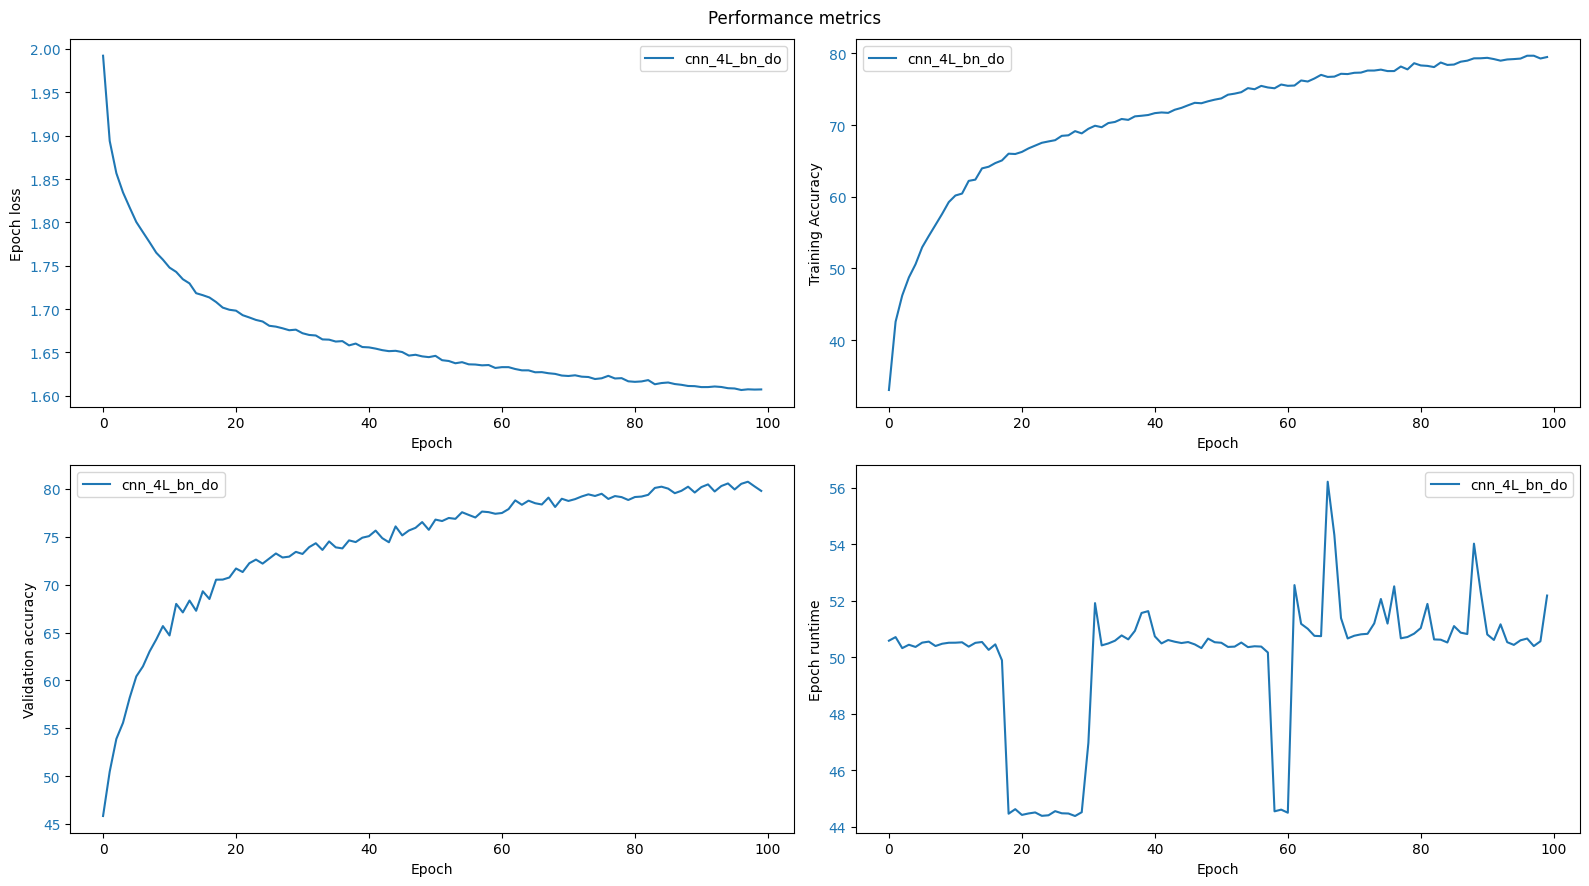

In [593]:
generate_epoch_plots(new_dict)

### Plot train performance metrics

In [595]:
new_dict = grid_results_with_activations_only4L['cnn_4L_bn_do']

In [596]:
new_dict.keys()

dict_keys(['model', 'losses', 'mini_batch_losses', 'train_accuracies', 'val_accuracies', 'epoch_times', 'train_time'])

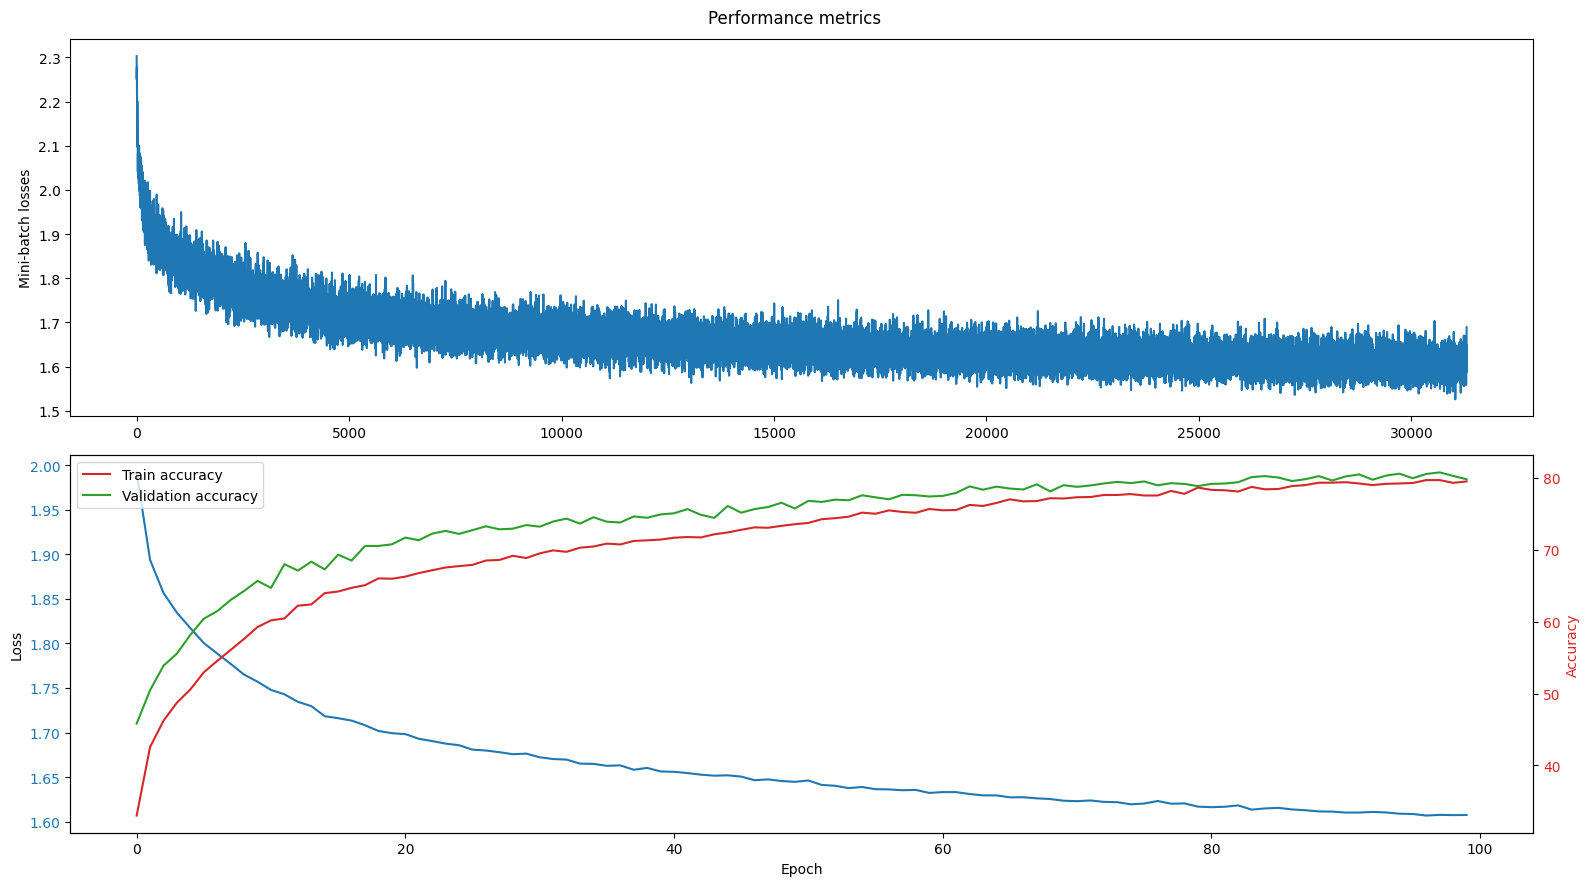

In [597]:
generate_training_plots(new_dict['mini_batch_losses'], new_dict['losses'], new_dict['train_accuracies'], new_dict['val_accuracies'], 'cnn_champion_performance.png')

In [598]:
print(f'Total Train time in gpu {new_dict['train_time']/60:.2f} min')

Total Train time in gpu 83.21 min


In [599]:
total_params = sum(p.numel() for p in new_dict['model'].parameters())
trainable_params = sum(p.numel() for p in new_dict['model'].parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 521866
Trainable parameters: 521866


### Model validation

In [600]:
cnn1_accuracy, cnn1_metrics, cnn1_confusion_matrix, cnn1_classification_report, cnn1_total_pred_time, cnn1_unit_pred_time = test_model(new_dict['model'], val_loader, device=device)

In [601]:
cnn1_accuracy, cnn1_total_pred_time, cnn1_unit_pred_time 

(0.7969, 0.08198830008041114, 8.198830008041113e-06)

In [602]:
print(cnn1_classification_report)

              precision    recall  f1-score   support

         0.0       0.86      0.79      0.82      1005
         1.0       0.93      0.89      0.91       974
         2.0       0.77      0.71      0.74      1032
         3.0       0.65      0.60      0.62      1016
         4.0       0.70      0.87      0.77       999
         5.0       0.76      0.58      0.66       937
         6.0       0.77      0.88      0.82      1030
         7.0       0.83      0.84      0.84      1001
         8.0       0.81      0.93      0.87      1025
         9.0       0.91      0.86      0.88       981

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.79     10000
weighted avg       0.80      0.80      0.79     10000



In [606]:
cnn1_metrics['y'] = cnn1_metrics['y'].apply(lambda x: classes[x])

In [607]:
cnn1_metrics

,y,precision,recall,F1,correct,count,accuracy
0,plane,0.860870,0.788060,0.822857,792,1005,0.788060
1,car,0.931257,0.890144,0.910236,867,974,0.890144
2,bird,0.772392,0.710271,0.740030,733,1032,0.710271
3,cat,0.650641,0.599409,0.623975,609,1016,0.599409
4,deer,0.699515,0.866867,0.774251,866,999,0.866867
5,dog,0.758669,0.583778,0.659831,547,937,0.583778
6,frog,0.772496,0.883495,0.824275,910,1030,0.883495
7,horse,0.833169,0.843157,0.838133,844,1001,0.843157
8,ship,0.809645,0.933659,0.867241,957,1025,0.933659
9,truck,0.905579,0.860347,0.882384,844,981,0.860347


In [610]:
class_names = {}
for i,name in enumerate(classes):
    class_names[i]=classes[i]

cnn1_confusion_matrix = cnn1_confusion_matrix.rename(class_names,axis=1).rename(class_names,axis=0)
cnn1_confusion_matrix

y_pred,plane,car,bird,cat,deer,dog,frog,horse,ship,truck
y,,,,,,,,,,
plane,792.0,6.0,25.0,14.0,25.0,5.0,7.0,13.0,98.0,20.0
car,7.0,867.0,5.0,8.0,4.0,3.0,12.0,2.0,31.0,35.0
bird,46.0,1.0,733.0,31.0,93.0,23.0,66.0,17.0,19.0,3.0
cat,15.0,1.0,50.0,609.0,86.0,95.0,92.0,44.0,11.0,13.0
deer,8.0,NaN,33.0,22.0,866.0,15.0,23.0,20.0,9.0,3.0
dog,4.0,1.0,37.0,192.0,50.0,547.0,42.0,57.0,7.0,NaN
frog,3.0,5.0,30.0,21.0,39.0,11.0,910.0,4.0,6.0,1.0
horse,5.0,NaN,26.0,24.0,67.0,17.0,13.0,844.0,3.0,2.0
ship,24.0,10.0,4.0,7.0,2.0,2.0,4.0,4.0,957.0,11.0


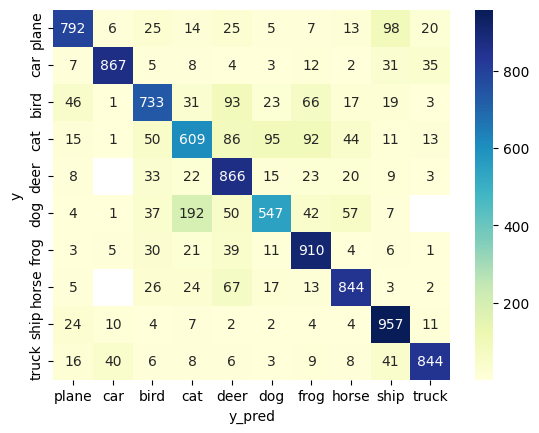

In [611]:
fig, ax = plt.subplots()
sns.heatmap(cnn1_confusion_matrix, annot=True, fmt='.0f', cmap='YlGnBu')
plt.savefig('cnn_champion_confusion_matrix.png')

# Two model comparison

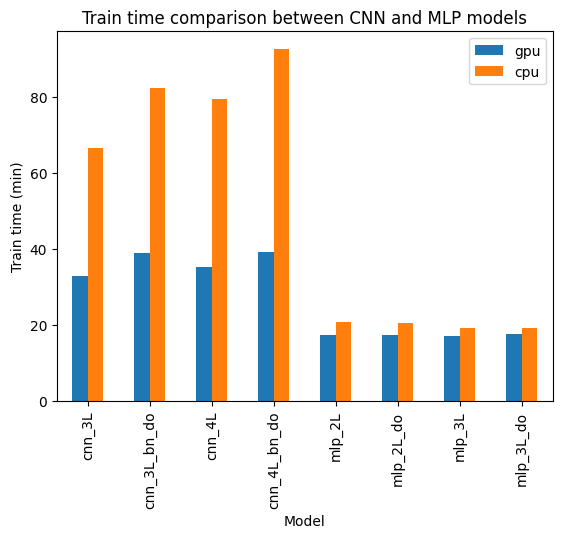

In [652]:
grid_results_with_activations_do2d_r = switch_dictionary(grid_results_with_activations_do2d)
grid_results_cpu_r = switch_dictionary(grid_results_cpu)

m4 = pd.DataFrame(grid_results_with_activations_do2d_r['train_time'].values(), grid_results_with_activations_do2d_r['train_time'].keys()).rename({0:'gpu'}, axis=1)
m5 = pd.DataFrame(grid_results_cpu_r['train_time'].values(), grid_results_cpu_r['train_time'].keys()).rename({0:'cpu'}, axis=1)

grid_resuls_mlp_r = switch_dictionary(grid_results_mlp)
grid_resuls_mlp_cpu_r = switch_dictionary(grid_results_mlp_cpu)

gpu = pd.DataFrame(grid_resuls_mlp_r['train_time'].values(), grid_resuls_mlp_r['train_time'].keys()).rename({0:'gpu'},axis=1)
cpu = pd.DataFrame(grid_resuls_mlp_cpu_r['train_time'].values(), grid_resuls_mlp_cpu_r['train_time'].keys()).rename({0:'cpu'}, axis=1)


comparison1 = m4.join(m5)
comparison2 = gpu.join(cpu)
comparison2 = comparison2.rename({'cnn_3L': 'mlp_3L', 'cnn_3L_do':'mlp_3L_do'},axis=0)
comparison = pd.concat([comparison1, comparison2])
comparison = comparison / 60

comparison = comparison.reset_index().rename({'index':'model'}, axis=1)

comparison.plot(x='model', y=['gpu','cpu'], kind='bar')
plt.title('Train time comparison between CNN and MLP models')
plt.ylabel('Train time (min)')
plt.xlabel('Model')
plt.savefig('cnn_train_time_comparison.png')
plt.show()

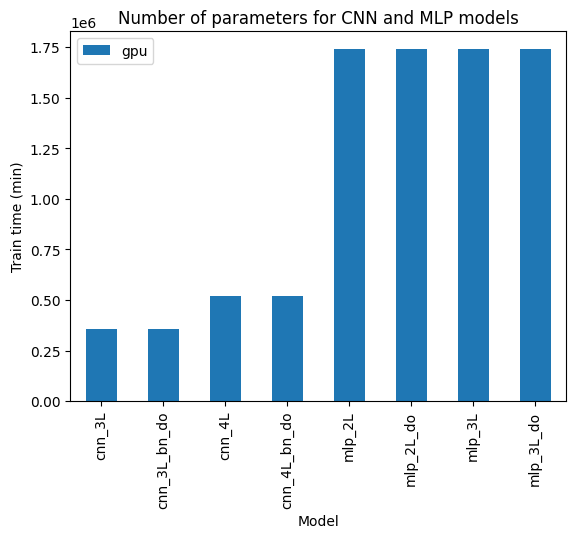

In [653]:
grid_results_with_activations_do2d_r = switch_dictionary(grid_results_with_activations_do2d)
grid_results_cpu_r = switch_dictionary(grid_results_cpu)

m4 = pd.DataFrame([sum(p.numel() for p in x.parameters()) for x in grid_results_with_activations_do2d_r['model'].values()], grid_results_with_activations_do2d_r['train_time'].keys()).rename({0:'gpu'}, axis=1)
#m5 = pd.DataFrame([sum(p.numel() for p in x.parameters()) for x in grid_results_cpu_r['model'].values()], grid_results_cpu_r['train_time'].keys()).rename({0:'cpu'}, axis=1)

grid_resuls_mlp_r = switch_dictionary(grid_results_mlp)
grid_resuls_mlp_cpu_r = switch_dictionary(grid_results_mlp_cpu)

gpu = pd.DataFrame([sum(p.numel() for p in x.parameters()) for x in grid_resuls_mlp_r['model'].values()], grid_resuls_mlp_r['train_time'].keys()).rename({0:'gpu'},axis=1)
#cpu = pd.DataFrame([sum(p.numel() for p in x.parameters()) for x in grid_resuls_mlp_cpu_r['model'].values()], grid_resuls_mlp_cpu_r['train_time'].keys()).rename({0:'cpu'}, axis=1)


comparison1 = m4 #.join(m5)
comparison2 = gpu #.join(cpu)
comparison2 = comparison2.rename({'cnn_3L': 'mlp_3L', 'cnn_3L_do':'mlp_3L_do'},axis=0)
comparison = pd.concat([comparison1, comparison2])
#comparison = comparison / 60
#comparison = comparison.rename({'cnn_3L': 'mlp_3L', 'cnn_3L_do':'mlp_3L_do'},axis=0)
comparison = comparison.reset_index().rename({'index':'model'}, axis=1)

comparison.plot(x='model', y=['gpu'], kind='bar')
plt.title('Number of parameters for CNN and MLP models')
plt.ylabel('Train time (min)')
plt.xlabel('Model')
plt.savefig('cnn_train_time_comparison.png')
plt.show()

# Single model train code

## Training

In [405]:
model = MLP()

criterion = nn.CrossEntropyLoss() # Suitable for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimization

(mlp1_trained_model, mlp1_train_losses, mlp1_mini_batch_losses, mlp1_train_accuracies, mlp1_epoch_times, mlp1_train_time_gpu) = train_model(model, trainloader, criterion, optimizer, num_epochs, device)

Begin training on cuda:0
Epoch 1, Loss: 1.653, Accuracy: 41.23%, Time: 14s
Epoch 2, Loss: 1.428, Accuracy: 49.67%, Time: 14s
Epoch 3, Loss: 1.307, Accuracy: 54.06%, Time: 14s
Epoch 4, Loss: 1.206, Accuracy: 57.42%, Time: 14s
Epoch 5, Loss: 1.123, Accuracy: 60.35%, Time: 14s
Epoch 6, Loss: 1.040, Accuracy: 63.20%, Time: 14s
Epoch 7, Loss: 0.956, Accuracy: 66.04%, Time: 14s
Epoch 8, Loss: 0.880, Accuracy: 68.72%, Time: 14s
Epoch 9, Loss: 0.808, Accuracy: 71.29%, Time: 14s
Epoch 10, Loss: 0.736, Accuracy: 73.72%, Time: 14s
Epoch 11, Loss: 0.672, Accuracy: 75.79%, Time: 14s
Epoch 12, Loss: 0.598, Accuracy: 78.58%, Time: 14s
Epoch 13, Loss: 0.546, Accuracy: 80.13%, Time: 14s
Epoch 14, Loss: 0.496, Accuracy: 82.30%, Time: 14s
Epoch 15, Loss: 0.459, Accuracy: 83.54%, Time: 14s
Epoch 16, Loss: 0.405, Accuracy: 85.47%, Time: 14s
Epoch 17, Loss: 0.371, Accuracy: 86.79%, Time: 14s
Epoch 18, Loss: 0.354, Accuracy: 87.24%, Time: 14s
Epoch 19, Loss: 0.325, Accuracy: 88.42%, Time: 14s
Epoch 20, Loss:

## Plot train performance metrics

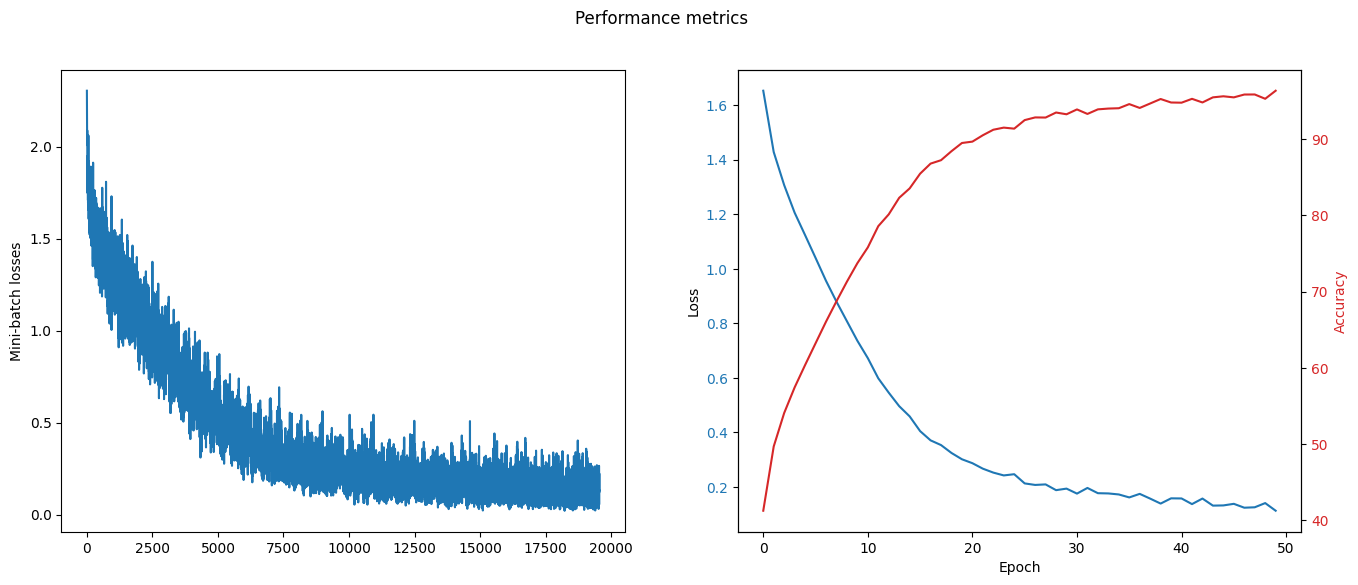

In [406]:
generate_training_plots(mlp1_mini_batch_losses, mlp1_train_losses, mlp1_train_accuracies)

In [407]:
print(f'Total Train time in cpu {mlp1_train_time_cpu/60:.2f} min')
print(f'Total Train time in gpu {mlp1_train_time_gpu/60:.2f} min')

Total Train time in cpu 11.68 min
Total Train time in gpu 11.84 min


## Model validation

In [408]:
mlp1_accuracy, mlp1_metrics, mlp1_confusion_matrix, mlp1_total_pred_time, mlp1_unit_pred_time = test_model(mlp1_trained_model, testloader, device=device)

In [409]:
mlp1_accuracy, mlp1_total_pred_time, mlp1_unit_pred_time 

(0.5338, 0.026353100111009553, 2.6353100111009553e-06)

In [410]:
mlp1_metrics

,y,precision,recall,F1,correct,count,accuracy
0,0,0.583184,0.652,0.615675,652,1000,0.652
1,1,0.669456,0.640,0.654397,640,1000,0.640
2,2,0.389520,0.446,0.415851,446,1000,0.446
3,3,0.344171,0.434,0.383901,434,1000,0.434
4,4,0.500000,0.452,0.474790,452,1000,0.452
5,5,0.452020,0.358,0.399554,358,1000,0.358
6,6,0.633962,0.504,0.561560,504,1000,0.504
7,7,0.571173,0.638,0.602740,638,1000,0.638
8,8,0.703400,0.600,0.647598,600,1000,0.600
9,9,0.579792,0.614,0.596406,614,1000,0.614


In [411]:
mlp1_confusion_matrix

y_pred,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0
y,,,,,,,,,,
0.0,652,28,74,26,30,16,13,31,76,54
1.0,47,640,22,29,8,12,13,23,43,163
2.0,80,14,446,98,115,68,61,73,23,22
3.0,24,17,126,434,47,153,69,73,19,38
4.0,43,8,152,95,452,42,73,96,21,18
5.0,14,7,115,265,64,358,37,103,18,19
6.0,21,30,100,152,87,39,504,25,11,31
7.0,32,14,52,82,69,62,11,638,8,32
8.0,145,62,31,35,22,14,6,17,600,68


<Axes: xlabel='y_pred', ylabel='y'>

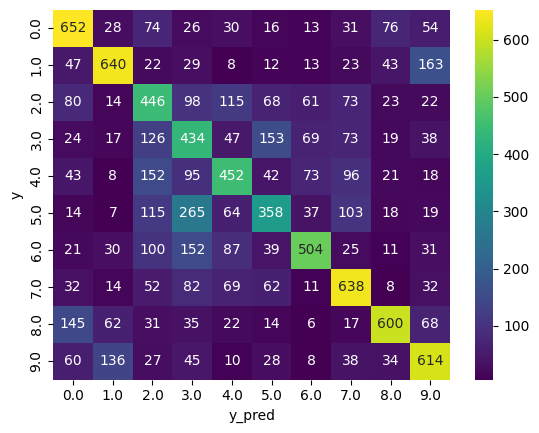

In [412]:
fig, ax = plt.subplots()
sns.heatmap(mlp1_confusion_matrix, annot=True, fmt='.0f', cmap='viridis')

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# 1. Define the CNN Architecture
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(32 * 8 * 8, num_classes) # Assuming input image size 32x32

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8) # Flatten the output for the fully connected layer
        x = self.fc(x)
        return x

# 2. Prepare Data (Example using CIFAR-10)
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

# 3. Initialize Model, Loss Function, and Optimizer
net = SimpleCNN(num_classes=10)
criterion = nn.CrossEntropyLoss() # Suitable for multi-class classification
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # Stochastic Gradient Descent

# 4. Training Loop (Gradient Descent)
num_epochs = 2
for epoch in range(num_epochs):  # loop over the dataset multiple times
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward() # Computes gradients
        optimizer.step() # Updates parameters using the computed gradients

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Define the CNN Architecture
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # Input: 3 channels (e.g., RGB)
            nn.BatchNorm2d(32), # Batch Normalization after Conv layer
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512), # Adjust input features based on image size and pooling
            nn.BatchNorm1d(512), # Batch Normalization for fully connected layer
            nn.ReLU(),
            nn.Dropout(0.5), # Dropout for regularization
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 2. Prepare Data (Example with dummy data)
# In a real scenario, you would load your dataset (e.g., CIFAR-10, MNIST)
# and use torchvision.datasets and torchvision.transforms.
dummy_data = torch.randn(64, 3, 32, 32) # Batch size, channels, height, width
dummy_labels = torch.randint(0, 10, (64,)) # 10 classes

dataset = TensorDataset(dummy_data, dummy_labels)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# 3. Instantiate Model, Loss Function, and Optimizer
num_classes = 10
model = SimpleCNN(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Training Loop (Gradient Descent)
num_epochs = 5
for epoch in range(num_epochs):
    model.train() # Set model to training mode (enables Batch Norm and Dropout)
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(dataloader):
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss / len(dataloader)}")

# 5. Evaluation (Example)
model.eval() # Set model to evaluation mode (disables Dropout, uses running stats for Batch Norm)
with torch.no_grad():
    # Perform inference on test data
    pass # Add your evaluation logic here

In [90]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(16 * 16 * 16, 10) # Example: assuming input image size leads to 16x16 after conv/pool

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = x.view(-1, 16 * 16 * 16)
        x = self.fc(x)
        return x

model = SimpleCNN()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 41418
Trainable parameters: 41418


In [ ]:


model = SimpleCNN(num_classes=10, conv_layers=3, batch_norm=False, dropout=False)



criterion = nn.CrossEntropyLoss() # Suitable for multi-class classification
#optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # Stochastic Gradient Descent
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimization
num_epochs=20

(cnn1_trained_model, cnn1_train_losses, cnn1_mini_batch_losses, cnn1_train_accuracies, cnn1_val_accuracies, cnn1_epoch_times, cnn1_train_time_gpu) = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)

results['model'] = cnn1_trained_model
results['losses'] = cnn1_train_losses
results['mini_batch_losses'] = cnn1_mini_batch_losses
results['train_accuracies'] = cnn1_train_accuracies
results['val_accuracies'] = cnn1_val_accuracies
results['epoch_times'] = cnn1_epoch_times
results['train_time'] = cnn1_train_time_gpu

In [ ]:
        '''  
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu4(self.bn4(self.conv4(x))))
        '''

In [245]:
model = SimpleCNN(num_classes=10, conv_layers=4, batch_norm=True, dropout=False)

Layer 1 output: 16.0*16.0, channels: 32
Layer 2 output: 8.0*8.0, channels: 64
Layer 3 output: 4.0*4.0, channels: 128
Layer 4 output: 2.0*2.0, channels: 256
Linear is 1024.0 to 128
Linear is 128 to 10
Batch normalization: True
Convolutional layers: 4
Dropout: False
Final image size before Linear FC: 2
Final channels before Linear FC: 256



Layer 1 output: 16.0*16.0, channels: 32
Layer 2 output: 8.0*8.0, channels: 64
Linear is 4096.0 to 128
Linear is 128 to 10
Batch normalization: True
Convolutional layers: 2
Dropout: True
Final image size before Linear FC: 8
Final channels before Linear FC: 64
Begin training on cuda:0
Epoch 1, Loss: 1.716, Accuracy: 44.02%, Validation accuracy: 55.14%,, Time: 49s
Epoch 2, Loss: 1.226, Accuracy: 56.30%, Validation accuracy: 60.80%,, Time: 49s
Epoch 3, Loss: 1.098, Accuracy: 61.01%, Validation accuracy: 66.62%,, Time: 51s
Epoch 4, Loss: 1.032, Accuracy: 63.73%, Validation accuracy: 66.99%,, Time: 51s
Epoch 5, Loss: 0.999, Accuracy: 64.95%, Validation accuracy: 67.44%,, Time: 53s

Layer 1 output: 16.0*16.0, channels: 32
Layer 2 output: 8.0*8.0, channels: 64
Layer 3 output: 4.0*4.0, channels: 128
Layer 4 output: 2.0*2.0, channels: 256
Linear is 1024.0 to 128
Linear is 128 to 10
Batch normalization: True
Convolutional layers: 4
Dropout: True
Final image size before Linear FC: 2
Final channels before Linear FC: 256
Begin training on cuda:0
Epoch 1, Loss: 1.554, Accuracy: 43.02%, Validation accuracy: 51.84%,, Time: 62s
Epoch 2, Loss: 1.204, Accuracy: 56.52%, Validation accuracy: 63.84%,, Time: 63s
Epoch 3, Loss: 1.064, Accuracy: 62.24%, Validation accuracy: 65.40%,, Time: 60s
Epoch 4, Loss: 0.987, Accuracy: 64.84%, Validation accuracy: 68.92%,, Time: 61s
Epoch 5, Loss: 0.923, Accuracy: 67.24%, Validation accuracy: 67.87%,, Time: 60s

Layer 1 output: 16.0*16.0, channels: 32
Layer 2 output: 8.0*8.0, channels: 64
Layer 3 output: 4.0*4.0, channels: 128
Layer 4 output: 2.0*2.0, channels: 256
Linear is 1024.0 to 128
Linear is 128 to 10
Batch normalization: False
Convolutional layers: 4
Dropout: False
Final image size before Linear FC: 2
Final channels before Linear FC: 256
Begin training on cuda:0
Epoch 1, Loss: 1.557, Accuracy: 42.38%, Validation accuracy: 51.83%,, Time: 53s
Epoch 2, Loss: 1.118, Accuracy: 59.74%, Validation accuracy: 64.41%,, Time: 52s
Epoch 3, Loss: 0.902, Accuracy: 68.09%, Validation accuracy: 69.66%,, Time: 52s
Epoch 4, Loss: 0.771, Accuracy: 73.25%, Validation accuracy: 72.94%,, Time: 54s
Epoch 5, Loss: 0.675, Accuracy: 76.48%, Validation accuracy: 74.23%,, Time: 53s

Layer 1 output: 16.0*16.0, channels: 32
Layer 2 output: 8.0*8.0, channels: 64
Layer 3 output: 4.0*4.0, channels: 128
Linear is 2048.0 to 128
Linear is 128 to 10
Batch normalization: False
Convolutional layers: 3
Dropout: False
Final image size before Linear FC: 4
Final channels before Linear FC: 128
Begin training on cuda:0
Epoch 1, Loss: 1.479, Accuracy: 46.16%, Validation accuracy: 56.79%,, Time: 47s
Epoch 2, Loss: 1.076, Accuracy: 61.80%, Validation accuracy: 66.17%,, Time: 49s
Epoch 3, Loss: 0.909, Accuracy: 68.12%, Validation accuracy: 68.69%,, Time: 49s
Epoch 4, Loss: 0.809, Accuracy: 71.90%, Validation accuracy: 70.62%,, Time: 48s
Epoch 5, Loss: 0.736, Accuracy: 74.46%, Validation accuracy: 70.77%,, Time: 47s

## Training on cpu

In [31]:
model = SimpleCNN(num_classes=10)

criterion = nn.CrossEntropyLoss() # Suitable for multi-class classification
#optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # Stochastic Gradient Descent
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimization

(trained_model, train_losses, mini_batch_losses, train_accuracies, epoch_times, cnn1_train_time_cpu) = train_model(model, train_loader, criterion, optimizer, num_epochs, device='cpu')


Begin training on cpu
Epoch 1, Loss: 1.442, Accuracy: 46.61%, Time: 117s
Epoch 2, Loss: 0.945, Accuracy: 66.17%, Time: 120s
Epoch 3, Loss: 0.736, Accuracy: 73.93%, Time: 123s
Epoch 4, Loss: 0.588, Accuracy: 79.32%, Time: 122s
Epoch 5, Loss: 0.467, Accuracy: 83.66%, Time: 122s
Epoch 6, Loss: 0.357, Accuracy: 87.34%, Time: 122s
Epoch 7, Loss: 0.274, Accuracy: 90.37%, Time: 122s
Epoch 8, Loss: 0.212, Accuracy: 92.49%, Time: 121s
Epoch 9, Loss: 0.174, Accuracy: 93.73%, Time: 121s
Epoch 10, Loss: 0.132, Accuracy: 95.35%, Time: 121s
Epoch 11, Loss: 0.132, Accuracy: 95.38%, Time: 121s
Epoch 12, Loss: 0.116, Accuracy: 95.93%, Time: 121s
Epoch 13, Loss: 0.115, Accuracy: 96.06%, Time: 119s
Epoch 14, Loss: 0.086, Accuracy: 97.05%, Time: 118s
Epoch 15, Loss: 0.095, Accuracy: 96.79%, Time: 118s
Epoch 16, Loss: 0.098, Accuracy: 96.70%, Time: 118s
Epoch 17, Loss: 0.077, Accuracy: 97.40%, Time: 118s
Epoch 18, Loss: 0.083, Accuracy: 97.22%, Time: 118s
Epoch 19, Loss: 0.079, Accuracy: 97.25%, Time: 118s